In [1]:
import validation

# Homework Assignment 2

In this homework we'll experiment with many aspects of neural networks to better understand how they work and implement them. This homework has 7 sections, with 60 points in total:
* Model weight initialization (12 points)
* Reviewing pytorch code (6 points)
* Evaluation and interpretation (18 points)
* Activation functions (5 points)
* Interpreting models (3 points)
* Pooling layers (6 points)
* Data Augmentation (10 points)

In [ ]:
# Fill in your name using the given format, GitHub handle, and sources
your_name = "BALA SUBRAMANI, ABITHA"
github_handle = "abi1402"
statement = """
            I used the provided lab materials and lecture notes as the primary reference.
            I also consulted the scikit-learn online documentation to understand Logistic Regression,
            SGDClassifier, and partial_fit usage. Additionally, I used an AI assistant to help
            clarify concepts, debug code, and get a better understanding of what was required.
            """

##### **Tips on using AI tools**
From experiences over the last years in this and other courses, we learned that the quality of assignment solutions has (somewhat surprisingly) gone down with the arrival of AI tools. This is in part because chatbots may not fully understand the question and thus make mistakes, but primarily because AI tools cause students to interact less with each other, and more often postpone work too long. 

**Note:** in this assignment we mimic a number of (real world) situations that make it hard to rely on AI tools. Hence, don't expect you can easily do this assignment in a very short amount of time. 

**Start early to make sure you have enough time to do the exercises, ask for help, and get regular feedback so you can improve your solutions.**

Recommendations:
* Using AI can help you do better ML engineering, but requires solid ML knowledge and programming skills to begin with to critically assess the responses. Make sure you understand the concepts taught in the course and do the labs first.
* Talk to fellow students (and the teaching team). Don't copy code but do ask questions and learn from each other. Share the enthousiasm of learning and solving problems.
* Always try to solve the assignment by yourself so that you really understand the question and the challenges. Using AI to understand and resolve errors, or to explain vague concepts is fine.


## Preparation - imports



In [3]:
# imports
# =======================
# Standard Python libs
# =======================
import os
import glob
import random
import urllib.request
from pathlib import Path

# =======================
# Numerical & plotting
# =======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# =======================
# PyTorch
# =======================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.utils.data import (
    Dataset,
    DataLoader,
    random_split,
    TensorDataset,
)
from torchvision import datasets, transforms
from torchvision.transforms import v2

# =======================
# Scikit-learn
# =======================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# =======================
# Jupyter / Visualization utils
# =======================
# Package not installed in the default Colab environment, so we first install it
#!pip install --quiet ipycanvas
from ipycanvas import Canvas
from IPython.display import display
import dotenv

dotenv.load_dotenv()
# DO NOT EDIT BELOW THIS LINE. If you do, your assignment may not be graded correctly.
NUM_EPOCHS_TO_RUN = int(os.getenv("NUM_EPOCHS", 20))


In [4]:

# =======================
# Device configuration
# =======================
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print("Current device:", device)
torch.manual_seed(42)

Current device: cpu


## Lab specific python package with helper functions

We have packaged some boilerplate code for this assignment as a python wheel. We'll call this the MLE package. Installing it via pip will install it like any other python package and then you can use it. The wheel file is provided for you in this repo. It should be in the same directory or colab workspace as your notebook.

In [5]:
try:
    ### Upload wheel file to Colab here
    ### or specify the directory of the wheel file here
    !pip install --quiet mle_course_package-0.1.1-py3-none-any.whl

    # Import the key constants, functions and classes from the package.
    # Don't make changes here.
    from mle_course_package.hw2.utils import (
        FINAL_CLASSES,
        N_CLASSES,
        train_model,
        evaluate,
        split_dataset,
        calculate_accuracy,
        extract_predictions_E4,
    )

    from mle_course_package.hw2.data import (
        AssignmentDataset,
        DatasetInterpret,
        DatasetAugmentationTrain,
        DatasetAugmentationTest,
        Dataset_RE,
    )

    from mle_course_package.hw2.models import (
        SimpleCNNModel,
        MLP_F1_G1,
        MLP_E1,
        MLP_conf,
    )

    from mle_course_package.hw2.visualisation import (
        plot_dists,
        plot_curve,
        plot_confusion_matrix,
        plot_learning_curves,
    )

except Exception as e:
    print(e)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Accessing the data
The data is available in the /data folder. If you need to load it somewhere else, you can also download it from Canvas as [`data.zip`](https://canvas.tue.nl/courses/32767/files?preview=6979609).

The expected folder structure for the data is:

```
. (i.e. root_dir)
├── Assignment_2_2026.ipynb/
└── data/
    ├── model_eval.pt
    ├── activation/
    ├── augmentation/
    ├── eval_subset2/
    ├── eval_subset3/
    ├── eval_subset4/
    ├── quickdraw_subset1/
    ├── quickdraw_subset2/
    └── train_subset1/
```

If you are running the notebook on Colab or in another directory, set `root_dir` to the directory where the data folder can be found.


In [6]:
import os
import sys

# Detect if running in Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    ### ATTENTION: Modify the root_dir to the directory of your assignment
    root_dir = "/content/drive/MyDrive/MLE course/HW2/"
else:
    # Local folder in the working directory
    # Set to the current working directory by default. Modify to a specific folder if needed.
    root_dir = os.getcwd()
    # root_dir = os.path.join(os.getcwd(), "")

# Make sure the folder exists
os.makedirs(root_dir, exist_ok=True)

In [7]:
# If you are using colab and uploaded the zip file, you can use this to expand the folder :)
# Adapt this code according to where you stored the dataset in your Drive.
# !unzip "/content/drive/MyDrive/MLE course/HW2/data.zip" -d "/content/drive/MyDrive/MLE course/HW2/data/"

## QuickDraw Dataset

This dataset is a collection of 50 millions drawings over 345 categories, such as animals, objects, etc. The drawings come from players of the game ***Quick, Draw!***  in which the aim is to draw the requested category in under 20 seconds and a machine learning model has to guess it. We highly recommend you to check out the dataset [here](https://quickdraw.withgoogle.com/data), and perhaps [play the game](https://quickdraw.withgoogle.com/) a little bit, to gain more insights into the data you will be working with throughout this assignment. Understanding your data always helps to make the right decisions 🤗.

> Note: The entire dataset is unnecessarily large for the scope of this assignment. To preserve your time and GPU resources, we will only work with subsets of it. Each section will use different subsets, specific to the exercise at hand.

In this assignment, we will explore neural networks for the purpose of image classification. Once you've familiarized yourself with the dataset, we will continue with the assignment questions.

**TIP: at the end of the homework you will be able to play the game with your own models: draw cats and dogs and many other things and see if your models can recognize them correctly.**



# Fully Connected Neural Networks

## Section 1: Model parameter initialization (12 points)

How you choose to initialise your model parameters is one of the most important aspects of deep learning. If you recall from the lecture, we expect the input variance to neither be too large nor too small as these may lead or exploding or vanishing gradients. Luckily for you, libraries such as pytorch, apply uniform initialisation to parameters by default. But there's a catch to parameter initialisation. They affect every component in your model. Let's go through the following questions to understand this better.

We will start with a simple MLP definition.

### Question M.1: Retrieving model weights (2 points)

In [8]:
from typing import Callable

class SimpleMLP(nn.Module):
    def __init__(self, activation_fn: Callable, n_classes: int, input_size: int):
        super().__init__()

        self.layers = nn.ModuleList(
            [
                nn.Linear(input_size, 256),
                nn.Linear(256, 128),
                nn.Linear(128, n_classes)
            ]
        )


        self.activation_fn = activation_fn
        self.input_size = input_size
        self.n_classes = n_classes


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        for layer in self.layers:
            x = layer(x)
            x = self.activation_fn(x)
        return x

Now we will initialise this model. Consider that we want to just understand how parameter initialisation works so we are going to use some arbitrary number for `input_size` and `n_classes` will have the value of `N_CLASSES` from our MLE package. Also, as a default, we will use `ReLU` as the activation function.

In [9]:
simple_mlp = SimpleMLP(nn.ReLU(), n_classes=N_CLASSES, input_size=768).to(device)

A good way to know how your model parameters are initialised is to look at their distribution. Implement a function named `visualize_weight_distribution` which will take a model as input and plot the weight distribution. You must use the already implemented `plot_dist` function. This question is essentially about understanding how to retrieve and inspect model weights.

In [10]:
# Implement
def visualize_weight_distribution(model):
    """
       Implement, use plot_dist

       HINT: Collect layer wise weight values and pass to plot_dist

       Example usage:
       fig = plot_dists(layer_wise_weight_dict, xlabel="Weight vals")

       The dictionary should be of the form:
       {'Layer 0': array([ 0.01622579,  0.01416634, -0.00073104, ...,  0.03283623,
        0.02184241, ...]),
        'Layer 1': array([...]),
        ...} 
    """
    layer_wise_weight_dict = {}

    layer_idx = 0
    for name, param in model.named_parameters():
        if "weight" in name:
            weights = param.detach().cpu().numpy().flatten()
            layer_wise_weight_dict[f"Layer {layer_idx}"] = weights
            layer_idx += 1

    fig = plot_dists(layer_wise_weight_dict, xlabel="Weight vals")
    return None

In [11]:
validation.signature_unchanged(visualize_weight_distribution)

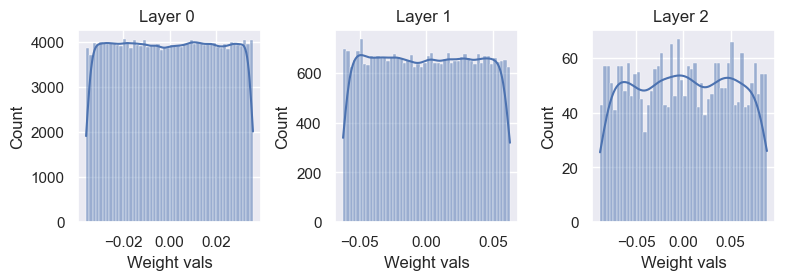

In [12]:
visualize_weight_distribution(simple_mlp)

### Question M.2: Re-initialize weights (2 points)

Let's look at your plots closely and the layerwise weight distribution. Since the default uniform initialisation was used, your weights are (hopefully) in an uniform distribution. Why use uniform distribution? Why not use a constant value to initialise the weights or sample from a normal distribution? The parameters will be trained anyway, right? Let's do a comparison.

For this question, you'll be implementing the following two functions which can take a model and initialise the model weights. You'll need to retrieve the weights from the given model and update them.

Note: for const_init, you must use `c > 0`.

In [13]:
# Implement
def const_init(model, c: float|None = None):
    """Implement. c is the const value which will be used to init your model (e.g. c=1 means all weights will be initialized to 1)"""
    if c is not None:
        assert c > 0.0

    for name, param in model.named_parameters():   # FIX: use named_parameters
        if "weight" in name:                       # only modify weights
            param.data.fill_(c)

def normal_init(model, std: float = 0.01):
    """Implement, std is the value of the standard deviation to create a normal distribution"""
    for name, param in model.named_parameters():   # FIX: use named_parameters
        if "weight" in name:
            param.data.normal_(0, std)

In [14]:
validation.signature_unchanged(normal_init)

### Question M.3: Weight distributions (1 point)

Now, create two new models with the `SimpleMLP` class with the same paramters as the `simple_mlp` model, named `const_init_model` and `normal_init_model`. Once done, call the initialization functions on them (`const_init` and `normal_init`) and then plot their weight distributions. We only expect you to create and initialize the models, and visualize the weight distribution. The function calls have already been provided in the subsequent cells.

In [15]:
# implement
def const_init_model_builder():
    model = SimpleMLP(nn.ReLU(), n_classes=N_CLASSES, input_size=768)
    return model

def normal_init_model_builder():
    model = SimpleMLP(nn.ReLU(), n_classes=N_CLASSES, input_size=768)
    return model

const_init_model = const_init_model_builder().to(device)
normal_init_model = normal_init_model_builder().to(device)

In [16]:
validation.signature_unchanged(const_init_model_builder)

In [17]:
validation.signature_unchanged(normal_init_model_builder)

In [18]:
const_init(const_init_model, 1)
normal_init(normal_init_model) # Uses the default std value

Now let's plot the weight distribution of both models.

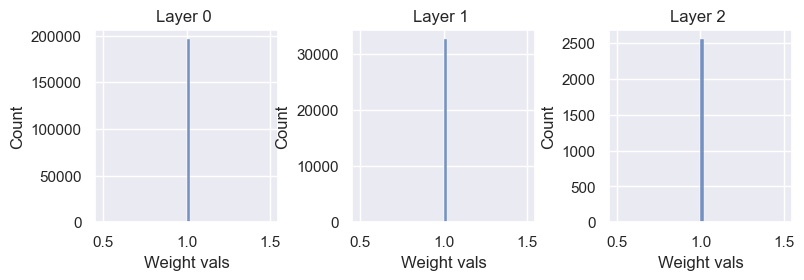

In [19]:
visualize_weight_distribution(model = const_init_model)

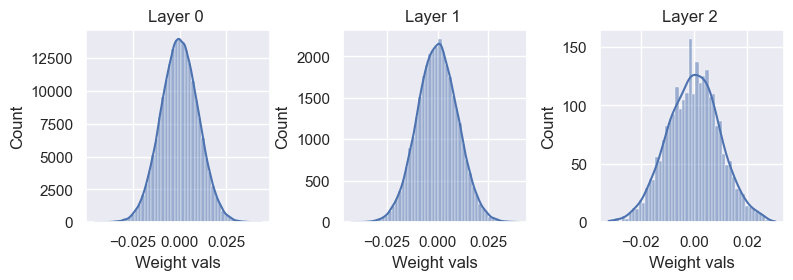

In [20]:
visualize_weight_distribution(model = normal_init_model)

### Question M.4: Gradients (2 points)

Now we will study how the weights in each layer are updated during training. In deep learning, we use gradient based methods to train or make our models learn. As such, the parameters will have gradients. How you initialise your parameters will affect the gradients as well as the activations. The best way to know your gradients and activations is to plot them. This time around, we are providing you with two partially implemented functions. You have to fill in the sections marked with IMPLEMENT and then call the functions to get both sets of plots (the gradients and the activations, per layer). Then repeat this for both models (with constant and normal initialization). The functions have a `data_set` parameter. For now we will use a dummy dataset as we are only aiming to understand parameter intialization. You will be using the QuickDraw dataset in the later sections of the homework.

In [21]:
class DummyDataset(Dataset):
    def __init__(self, device=torch.device("cpu")):
        self.X = torch.randn(128, 1, 768, device=device)
        self.y = torch.randint(0, 10, (128,), device=device)
    def __len__(self):
        return self.X.size()[0]
    def __getitem__(self, idx):
        return {
            "features": self.X[idx],
            "label": self.y[idx]
        }

DUMMY_DATASET = DummyDataset(device=device)

In [22]:
# Implement
def visualize_gradients(model, data_set, device=torch.device("cpu"), color="C0"):
    """
        model - model to visualise
        data_set - the provided dummy dataset
        device - device to send the model to, cuda / cpu
    """
    model.eval()

    # IMPLEMENT: create a dataloader, with a batch size of your choice
    dataloader = DataLoader(data_set, batch_size=32, shuffle=False)
    model.zero_grad()

    # IMPLEMENT: pass a batch to your model

    # IMPLEMENT: calculate the cross entropy loss

    # IMPLEMENT: call loss.backward()

    # IMPLEMENT: retrieve the gradients of the model params and add them to the grads dictionary
    # pass a batch to your model
    batch = next(iter(dataloader))
    x = batch["features"].to(device)
    y = batch["label"].to(device)

    outputs = model(x)

    # calculate the cross entropy loss
    loss = F.cross_entropy(outputs, y)

    # call loss.backward()
    loss.backward()
    grads = {}
    for layer_index, layer in enumerate(model.layers):
        grads[f"Layer {layer_index}"] = layer.weight.grad.detach().cpu().numpy().flatten()


    model.zero_grad()

    # check
    assert grads

    ## Plotting
    fig = plot_dists(grads, color=color, xlabel="Grad magnitude")
    fig.suptitle("Gradient distribution", fontsize=14, y=1.05)
    plt.show()
    plt.close()


def visualize_activations(model, data_set, device=torch.device("cpu"), color="C0"):
    """
    This function plots the visualisations and prints the variances in the activations
        model - model to visualise
        data_set - the dataset used in the hw, as a PyTorch Dataset (or use the provided one)
        device - device to send the model to, cuda / cpu

    """
    model.eval()

    # IMPLEMENT: create a dataloader, with a batch size of your choice
    dataloader = DataLoader(data_set, batch_size=32, shuffle=False)

    # IMPLEMENT: pass a batch to your model
    batch = next(iter(dataloader))
    x = batch["features"].to(device)

    # IMPLEMENT: create layer wise activation dict / map
    activations = {}
    with torch.no_grad():
        for layer_index, layer in enumerate(model.layers):
            x = layer(x)
            x = model.activation_fn(x)
            activations[f"Layer {layer_index}"] = x.detach().cpu().numpy().flatten()

    # check
    assert activations

    ## Plotting
    fig = plot_dists(activations, color=color, stat="density", xlabel="Activation vals")
    fig.suptitle("Activation distribution", fontsize=14, y=1.05)
    plt.show()
    plt.close()

    # this will print the variances
    for key in sorted(activations.keys()):
        print(f"{key} - Variance: {np.var(activations[key])}")

Now visualise the 3 models you've created so far.

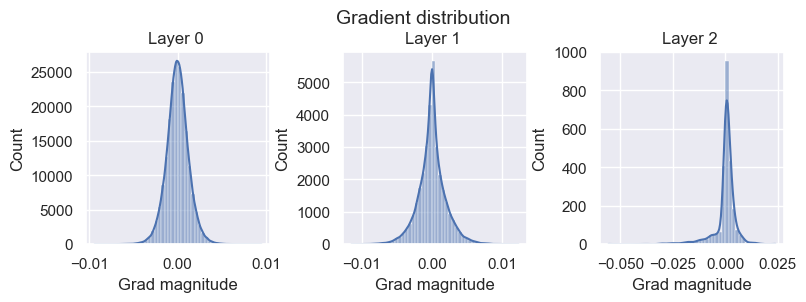

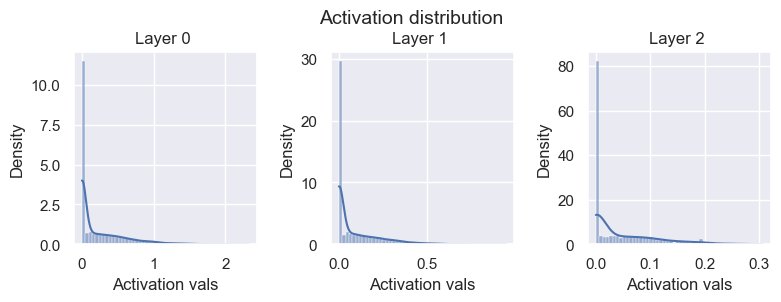

Layer 0 - Variance: 0.111200250685215
Layer 1 - Variance: 0.016932621598243713
Layer 2 - Variance: 0.0037512301933020353


In [23]:
visualize_gradients(model = simple_mlp, device=device, data_set=DUMMY_DATASET)
visualize_activations(model = simple_mlp, device=device, data_set=DUMMY_DATASET)

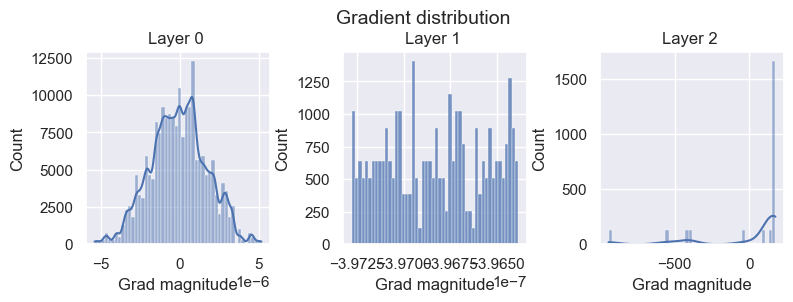

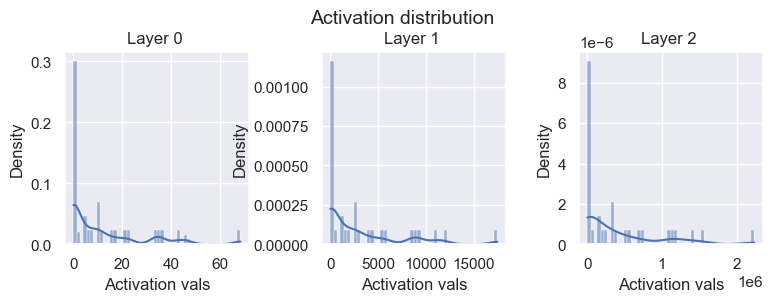

Layer 0 - Variance: 287.12542724609375
Layer 1 - Variance: 18816992.0
Layer 2 - Variance: 308297662464.0


In [24]:
visualize_gradients(model = const_init_model, device=device, data_set=DUMMY_DATASET)
visualize_activations(model = const_init_model, device=device, data_set=DUMMY_DATASET)

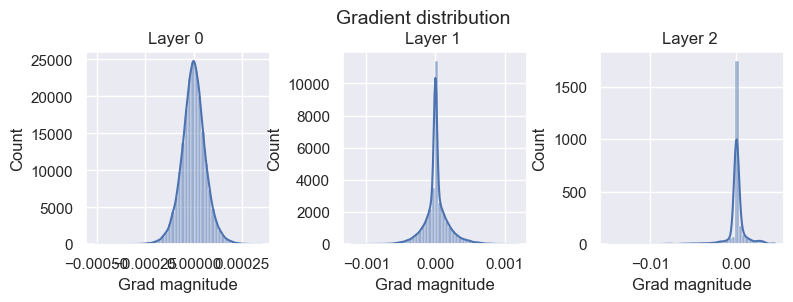

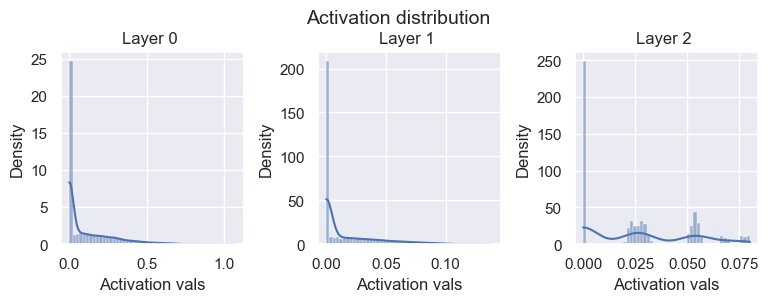

Layer 0 - Variance: 0.025161810219287872
Layer 1 - Variance: 0.000620627892203629
Layer 2 - Variance: 0.0006502147880382836


In [25]:
visualize_gradients(model = normal_init_model, device=device, data_set=DUMMY_DATASET)
visualize_activations(model = normal_init_model, device=device, data_set=DUMMY_DATASET)

### Question M.5: Interpretation (5 points)
#### Question M.5.1 (1 point)
From your plots, answer the following questions:

**What would have happened if you used `c = 0.0` in `const_init`?**
- *A*. It is the same as any other value for c.
- *B*. The gradients will be very large
- *C*. The activations will be infinite

#### Question M.5.2 (1 point)

**Let's look at the plot for the `simple_mlp` model. Which of the following is true?**
- *A*. The gradients will explode
- *B*. The activations are constant
- *C*. The variance in activation gets lower as layers progress


#### Question M.5.3 (1 point)
**What is the relationship between gradients and activations in terms of variance in your plots?**
- *A*. Gradients increase or decrease with activations
- *B*. They are not related
- *C*. The activations remain the same almost

#### Question M.5.4 (1 point)
**For the `normal_init_model`, what do the variance values you get mean?**
- *A*. Variance changes by very small margins or not at all when rounded to the 2 digits after decimal point
- *B*. Variance changes rapidly
- *C*. The values are in a distribution

#### Question M.5.5 (1 point)
**Call `visualize_activation`s and `visualize_gradients` again in new notebook cells on a new model using normal_init. What may happen when you select a very high value for std? Base your answer from the variance values you observe.**
- *A*. The gradients will explode
- *B*. The variance values form an exponential series
- *C*. The activations will become negative

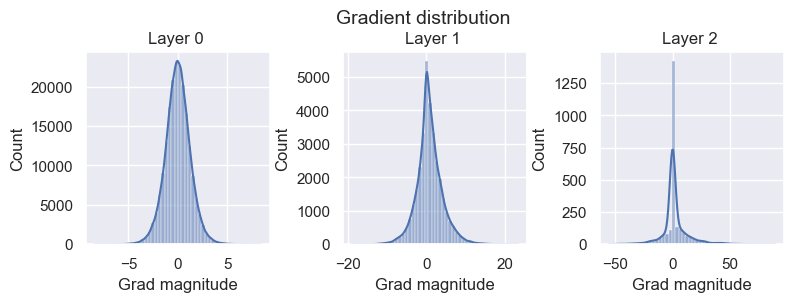

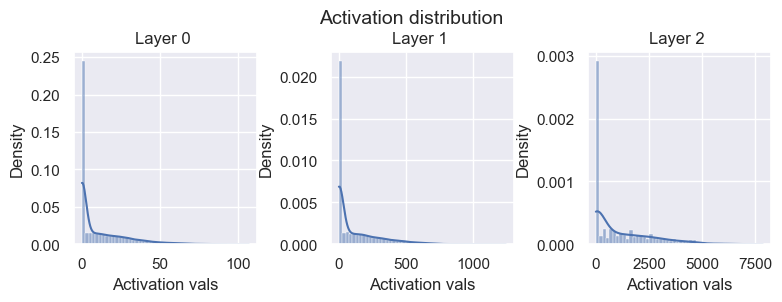

Layer 0 - Variance: 256.4115295410156
Layer 1 - Variance: 30145.89453125
Layer 2 - Variance: 2078689.375


In [26]:
high_std_model = SimpleMLP(nn.ReLU(), n_classes=N_CLASSES, input_size=768).to(device)

normal_init(high_std_model, std=1.0)

visualize_gradients(model=high_std_model, device=device, data_set=DUMMY_DATASET)
visualize_activations(model=high_std_model, device=device, data_set=DUMMY_DATASET)

**Your answers should be in the following cell.** Fill in the correct answer the variable. For reference, `Q_M_5_1` refers to `M.5.1`.

*Don't change the name of the variables!*

In [27]:
Q_M_5_1 = 'B'
Q_M_5_2 = 'C'
Q_M_5_3 = 'A'
Q_M_5_4 = 'A'
Q_M_5_5 = 'A'

## Section 2: Reviewing a Fully Connected Neural Network (6 points)
*Use dataset:* `quickdraw_subset1` *for this section.*


---

Now that we have a basic understanding of how learning works in a neural network, we'll develop an image recognition model using a fully connected neural network based on the QuickDraw dataset. To speed up the process, imagine you asked your preferred chatbot (e.g., ChatGPT, Gemini) to implement the neural network definition and training procedure. We already provide that code below :). As a responsible engineer, however, you first validate and correct the implementation given by the LLM before using it in practice (or presenting it to your manager).

In the following questions, you will examine the model definition, training and evaluation procedures. Use the knowledge you've gained throughout the course (lectures, labs) to review the implementation and correct it wherever needed. There may be missing function calls, entire missing layers or components, illogical hyperparameter settings, wrong attributes, and other bugs. Of course you are free to test the model and training/evaluation code any way you like to make sure they work as expected.

### Question R.1: Review model class implementation (2 points)
In the next cell, there is an already defined architecture of the neural network you will train. The neural network should be composed of 3 fully connected layers with hidden dimensions 256. The model should also use dropout and batch normalization to help stabilize training and prevent overfitting.
Review and correct the implementation of the model class `MLP_R1`.



In [28]:
# Review
class MLP_R1(nn.Module):
    """
    Defines a simple Multi-Layer Perceptron (MLP) model using PyTorch.

    Args:
        num_classes: Number of output classes
    """
    def __init__(self, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, num_classes)

        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(256)

        self.dropout = nn.Dropout(0.7)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        return self.fc3(x)

### Question R.2: Review training procedure (2 points)
In the next cell, we have the training procedure. This function trains a model and evaluates its performance. It first splits the dataset into training (70%), validation (20%), and test (10%) subsets, then creates data loaders to process the data in batches. Using the Adam optimizer, it trains the model for a specified number of epochs. In each epoch, the model performs forward passes on the training batches, computes the loss, backpropagates gradients, and updates its parameters. It calculates the average training loss and accuracy, then evaluates the model to obtain validation loss and accuracy. These metrics are stored after every epoch. Once training is complete, the model is evaluated on the test set, and the final test loss and accuracy are printed. The function returns the recorded history of training and validation metrics.

Review and correct the training loop.

In [29]:
# Review
def train_model_debug(model, dataset, criterion, batch_size, epochs=20, learning_rate=1e-3, device=torch.device("cpu")):
    model = model.to(device)
    train_size = int(0.7 * len(dataset))
    validation_size = int(0.2 * len(dataset))
    test_size = len(dataset) - train_size - validation_size

    train_dataset, validation_dataset, test_dataset = random_split(
        dataset,
        [train_size, validation_size, test_size]
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    optimizer = Adam(model.parameters(), lr=learning_rate)

    # Store history for plotting
    history = {"train_accuracy": [], "val_accuracy": [], "train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs)):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for imgs, labels in tqdm(train_loader):
            imgs = imgs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            train_correct += preds.eq(labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        validation_loss, validation_acc = evaluate(model, validation_loader, criterion, device)

        # Store values in history
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(validation_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(validation_loss)
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Training loss: {train_loss:.4f} | "
            f"Training acc: {train_acc:.4f} | "
            f"Validation loss: {validation_loss:.4f} | "
            f"Validation acc: {validation_acc:.4f}"
        )

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(
        f"Test loss: {test_loss:.4f} | "
        f"Test acc: {test_acc:.4f}"
    )
    return history

### Question R.3: Review evaluation procedure (2 points)
Finally, we have the evaluation procedure `evaluate_debug`. This function evaluates a trained model on a given dataset and computes its average loss and accuracy. For each batch in the provided data loader, the function performs a forward pass, computes the loss, and accumulates the total loss weighted by batch size. It also predicts the class label and counts how many predictions are correct. After processing all batches, it computes the average loss over the entire dataset and the overall accuracy, and returns both values.


Review and correct it wherever needed.

In [30]:
# Review
def evaluate_debug(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc

Now that we have all components, let's train the model using batch size 128.

Load the dataset `quickdraw_subset1` with the provided functions from the `mle_course_package`.

In [31]:
# This code should not be modified.

# Load the dataset
dataset_R1 = Dataset_RE(os.path.join(root_dir, "data/quickdraw_subset1"))
num_classes_R1 = len(dataset_R1.classes)

# Initialize the model
mlp_model_R1 = MLP_R1(num_classes_R1).to(device)

# Start training.
history = train_model_debug(mlp_model_R1, dataset_R1, criterion=nn.CrossEntropyLoss(), batch_size=128, epochs=NUM_EPOCHS_TO_RUN, device=device)

100%|██████████| 1627/1627 [00:06<00:00, 234.39it/s]


  0%|          | 0/465 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:07<02:27,  7.76s/it]

Epoch 1/20 | Training loss: 1.6221 | Training acc: 0.5111 | Validation loss: 1.1256 | Validation acc: 0.6642


100%|██████████| 1627/1627 [00:07<00:00, 231.35it/s]


...

  0%|          | 0/465 [00:00<?, ?it/s]

100%|██████████| 20/20 [02:44<00:00,  8.22s/it]

Epoch 20/20 | Training loss: 1.1305 | Training acc: 0.6707 | Validation loss: 0.8479 | Validation acc: 0.7488


  0%|          | 0/233 [00:00<?, ?it/s]

Test loss: 0.8523 | Test acc: 0.7485


Great job! You've trained a classification network implemented with the help of LLMs and reviewed by you!
Let's take a look at the learning curve and see how the training progressed.

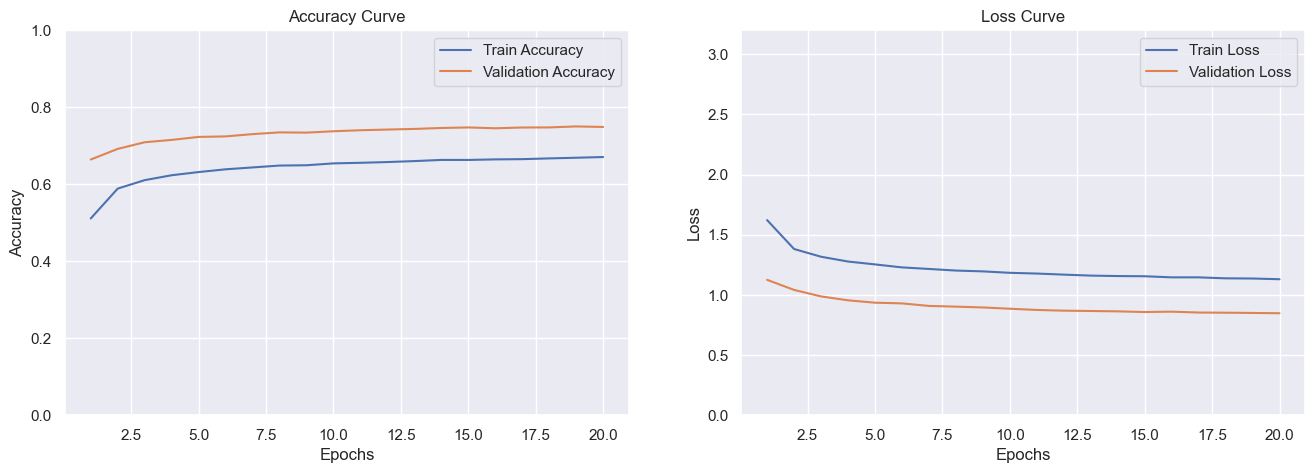

In [32]:
# This code should not be modified
plot_curve(history)

## Section 3: Evaluation & Interpretation (18 points)

*Throughout this section we will use various data subsets for evaluation purposes.*


---
Accuracy provides an overall measure of model performance but does not reveal how well the model predicts individual classes. In the next section, we will examine model performance at the class level to gain deeper insights into its behavior.

To preserve your GPU resources and time 😉, we provide you with an already trained fully connected neural network `model_eval.pt`. To gain better insights into the model we give, we give you the learning curves from training time.
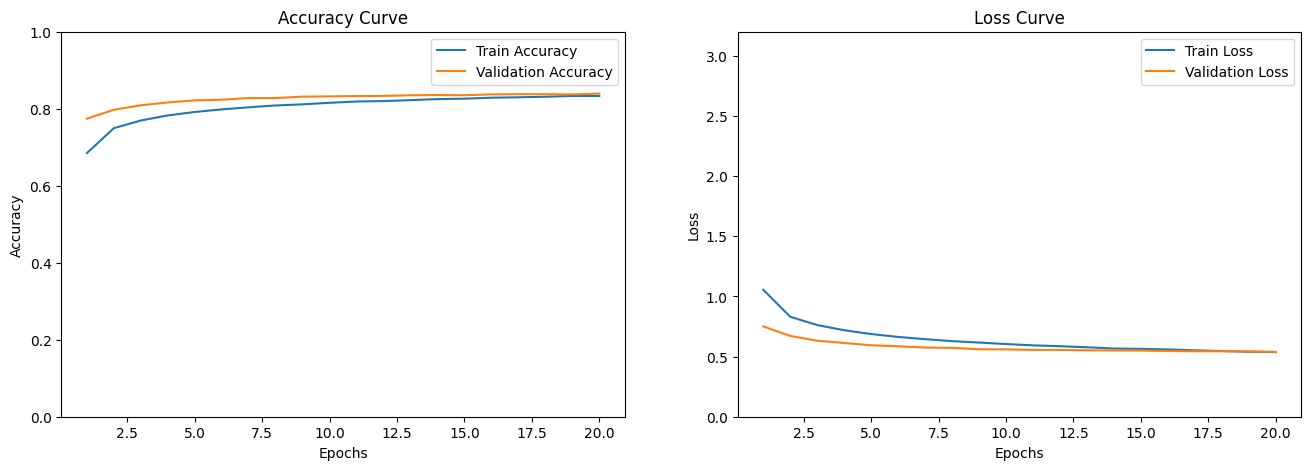




The model has been trained on a subset of the QuickDraw dataset. Below, we provide the class count distribution of the entire dataset before being split in training, validation and test splits (70%/20%/10%).


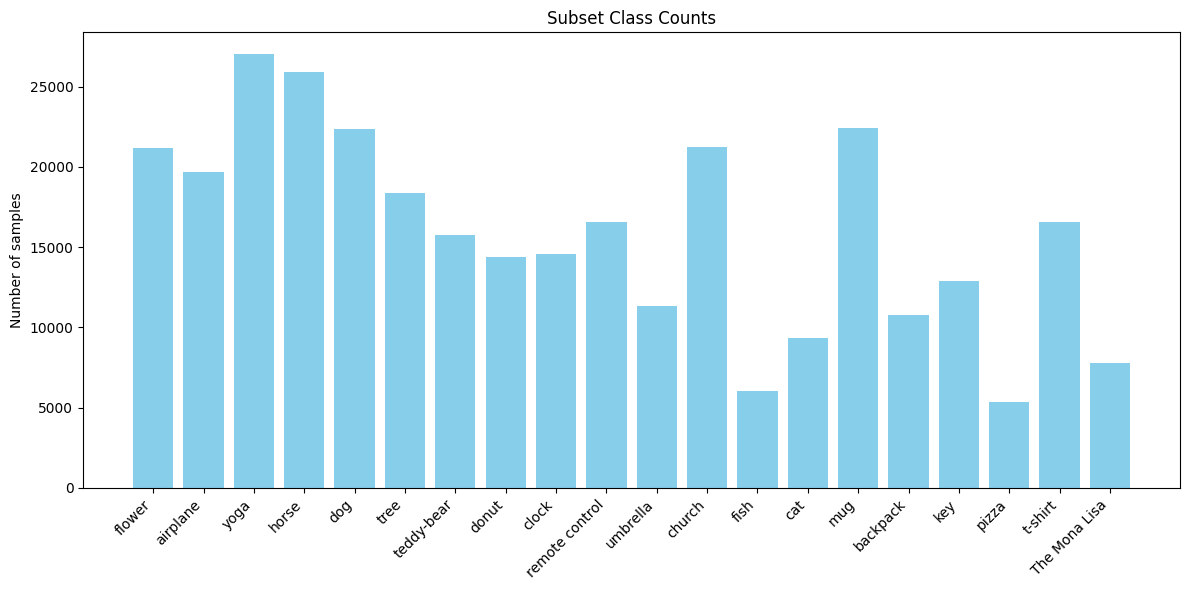

### Question E.1: Extract predictions (2 points)

*Use dataset:* `eval_subset2` *in this section.*

---

Use the already trained model we provide you (`model_eval`) to make predictions on the provided held-out test using `eval_subset2`. Implement a function `extract_predictions` which returns two `numpy` arrays: `y_true` and `y_pred` referring to the true and predicted classes for each instance in the test dataset. Then, calculate and plot the confusion matrix.

In [33]:
# This code should not be modified

# Load the dataset
test_dataset_E1 = Dataset_RE(os.path.join(root_dir, "data/eval_subset2"))
num_classes_E1 = len(test_dataset_E1.classes)
class_names_E1 = [s.removesuffix('.npy') for s in test_dataset_E1.classes]
test_loader_E1 = DataLoader(test_dataset_E1, batch_size=128, shuffle=False)

# Load already trained model weights
mlp_model_E1 = MLP_E1(num_classes_E1)
mlp_model_E1.load_state_dict(torch.load(f"{root_dir}/data/model_eval.pt", map_location=device))
mlp_model_E1.to(device)

MLP_E1(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=20, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [34]:
# This code should not be modified

# Evaluate model on the test set
_, test_acc_E1 = evaluate(mlp_model_E1, test_loader_E1, nn.CrossEntropyLoss(), device)

print(
    f"Test acc: {test_acc_E1:.4f}"
)

  0%|          | 0/248 [00:00<?, ?it/s]

Test acc: 0.8329


In [35]:
# Implement
def extract_predictions(model, test_loader, device=torch.device("cpu")):
    
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

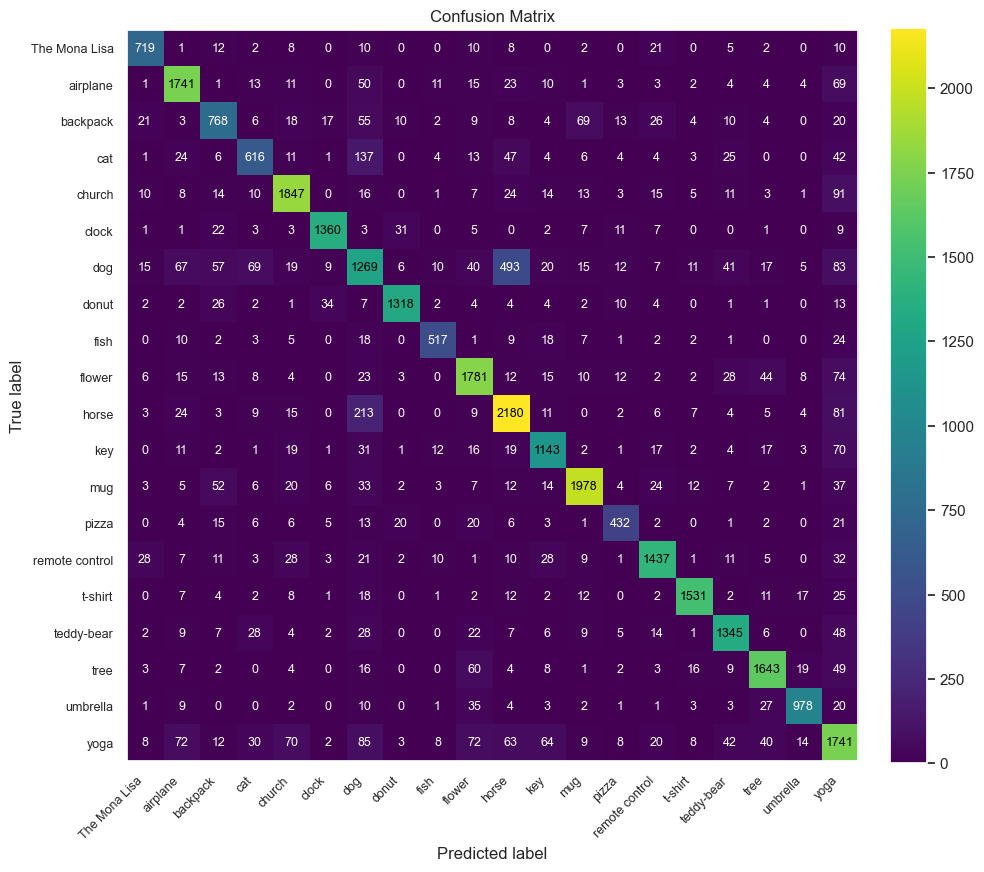

In [36]:
### This code should not be modified

# Extract predictions
y_true_E1, y_pred_E1 = extract_predictions(mlp_model_E1, test_loader_E1, device=device)

# Calculate confusion matrix
cm_E1 = confusion_matrix(y_true_E1, y_pred_E1)

# Plot confusion matrix
plot_confusion_matrix(
    cm_E1,
    class_names_E1,
    exercise="E1",
    figsize=(10, 10),
    font_size=9,
    label_size=9,
)

### Question E.2: Interpret the confusion matrix (3 points)
**Interpret the results of the confusion matrix and select the correct statements. Base your answers solely on the values of the confusion matrix as they are given.**
- *A*. The confusion matrix shows the model correctly classifies both
*airplane* and *yoga* class at similar rate.
- *B*. The confusion matrix shows that the model correctly classifies class *airplane* considerably more often than *yoga* class.
- *C*. The confusion matrix shows that the model correctly classifies class *yoga* considerably more often than *airplane* class.
- *D*. Prediction performance cannot be compared across classes from this plot alone; the confusion matrix should be normalized by row.
- *E*. Prediction performance cannot be compared across classes from this plot alone; the confusion matrix should be normalized by column.
- *F*. Comparing class-wise performance cannot be inferred from a confusion matrix.
- *G*. Class *dog* is most often misclassified as *horse* and *yoga*.
- *H*. Class dog is most often misclassified as *horse* and *cat*.

In [37]:
# add your answer here. do not change the variable name.
E_2_answer = "A, D, G"

### Question E.3: Calculate the confusion matrix for a new use case (2 points)

*Use dataset:* `eval_subset3` *in this section.*

---


Imagine this scenario: In a kindergarten class, children are learning to draw objects belonging to predefined categories (*clock*, *horse*, *dog*, *teddy bear*, *cat*, etc.). Because they are still learning how to do it, drawings sometimes resemble the wrong category. For example, a full-body drawing of a dog may be mistaken for that of a cat.

To analyze these patterns, the teacher uses the neural network classifier given above to speed up interpreting the children's drawings. The classifier serves as an assessment tool: it reveals how drawings are interpreted (predicted label), even when the child intended a different object (ground truth label).

Before using it in practice, the teacher is particularly interested in understanding the following : *how certain can she be about the predictions of a certain class?* This will help her identify which categories of drawings are most difficult to interpret, perhaps because of visual similarities to other categories, like in the case of dogs and cats.

For this reason, we will use the trained classifier to evaluate these patterns. Implement a function `calculate_confusion_matrix` that computes a confusion matrix designed to highlight the predictive reliability and visualize it using the given `plot_confusion_matrix`.

In [38]:
### This code should not be modified

# Load the dataset
test_dataset_E3 = Dataset_RE(os.path.join(root_dir, "data/eval_subset3"))
num_classes_E3 = len(test_dataset_E3.classes)
class_names_E3 = [s.removesuffix('.npy') for s in test_dataset_E3.classes]
test_loader_E3 = DataLoader(test_dataset_E3, batch_size=128, shuffle=False)

In [39]:
### This code should not be modified

y_true_E3, y_pred_E3 = extract_predictions(mlp_model_E1, test_loader_E3, device=device)

In [40]:
# Implement
def calculate_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred).astype(float)
    col_sums = cm.sum(axis=0, keepdims=True)
    col_sums[col_sums == 0] = 1.0
    cm = cm / col_sums
    return cm

cm_E3 = calculate_confusion_matrix(y_true_E3, y_pred_E3)

In [41]:
validation.signature_unchanged(calculate_confusion_matrix)

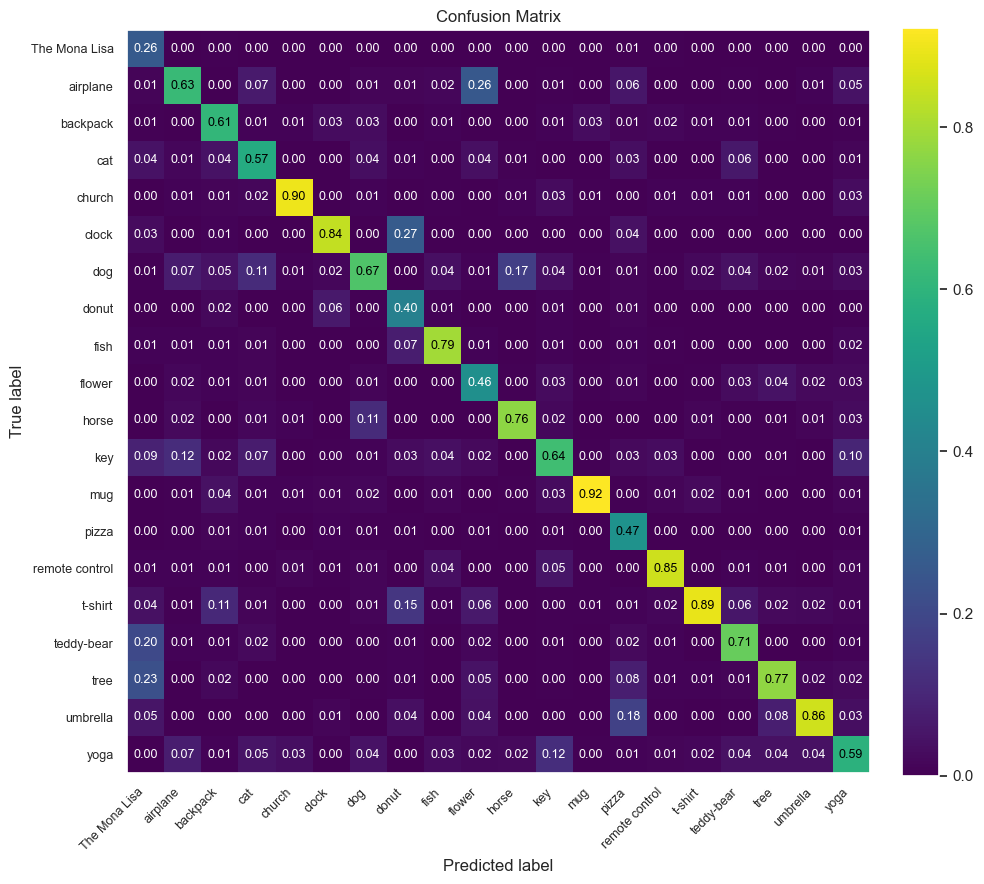

In [42]:
### This code should not be modified

plot_confusion_matrix(
    cm_E3,
    class_names_E1,
    exercise="E3",
    figsize=(10, 10),
    font_size=9,
    label_size=9,
)

### Question E.4: Interpret the confusion matrix again (3 points)

**Solely based on the confusion matrix calculated above, select the correct statements:**
- *A*. The classifier is unreliable when identifying pizzas; the majority of drawings classified as *pizza* correspond to other categories.
- *B*. When the system predicts *cat*, the input is more likely to be a *dog* than an actual *cat*.
- *C*. Fewer than 5% of drawings classified as *horse* are actually *dog* drawings.
- *D*. The model demonstrates higher precision when predicting *teddy bear* compared to when it predicts *horse*.
- *E*. If the model predicts *cat*, there is a less than 20% probability that the child actually intended to draw a *cat*.
- *F*. *Mug* predictions are highly trustworthy; most drawings interpreted as *mug* indeed correspond to that category.
- *G*. The category *donut* suffers from a high (>15%) False Discovery Rate (many non-*donut* drawings are incorrectly classified as *donut*).
- *H*. Among all categories, the model is least likely to generate a False Positive when predicting *clock*.

In [43]:
# Fill in the correct answer. Don't change the name of the variable
E_4_answer = "A, F, G"

### Question E.5: Plot pixel intensity distribution (2 points)

*Use dataset:* `eval_subset4` and `train_susbet1` *in this section.*

---


In this section, we will investigate model performance on a different held-out test set `eval_subset4`. First off, let's calculate the accuracy on the new evaluation set.

In [44]:
### This code should not be modified

# Load dataset
train_dataset_E4 = Dataset_RE(os.path.join(root_dir, "data/train_subset1"))
test_dataset_E4 = Dataset_RE(os.path.join(root_dir, "data/eval_subset4"))
num_classes_E4 = len(test_dataset_E4.classes)
class_names_E4 = [s.removesuffix('.npy') for s in test_dataset_E4.classes]
train_loader_E4 = DataLoader(train_dataset_E4, batch_size=128, shuffle=False)
test_loader_E4 = DataLoader(test_dataset_E4, batch_size=128, shuffle=False)

# Calculate accuracy on eval_2 set
test_acc_E4 = calculate_accuracy(mlp_model_E1, test_loader_E4, device=device)
print(f"Test acc: {test_acc_E4:.4f}")

  0%|          | 0/279 [00:00<?, ?it/s]

Test acc: 0.5527


Surprisingly, the accuracy on this new test set is considerably lower than what we've seen before. Let's investigate more closely what happens with the model predictions. Use the given `plot_confusion_matrix` function to further investigate model performance.

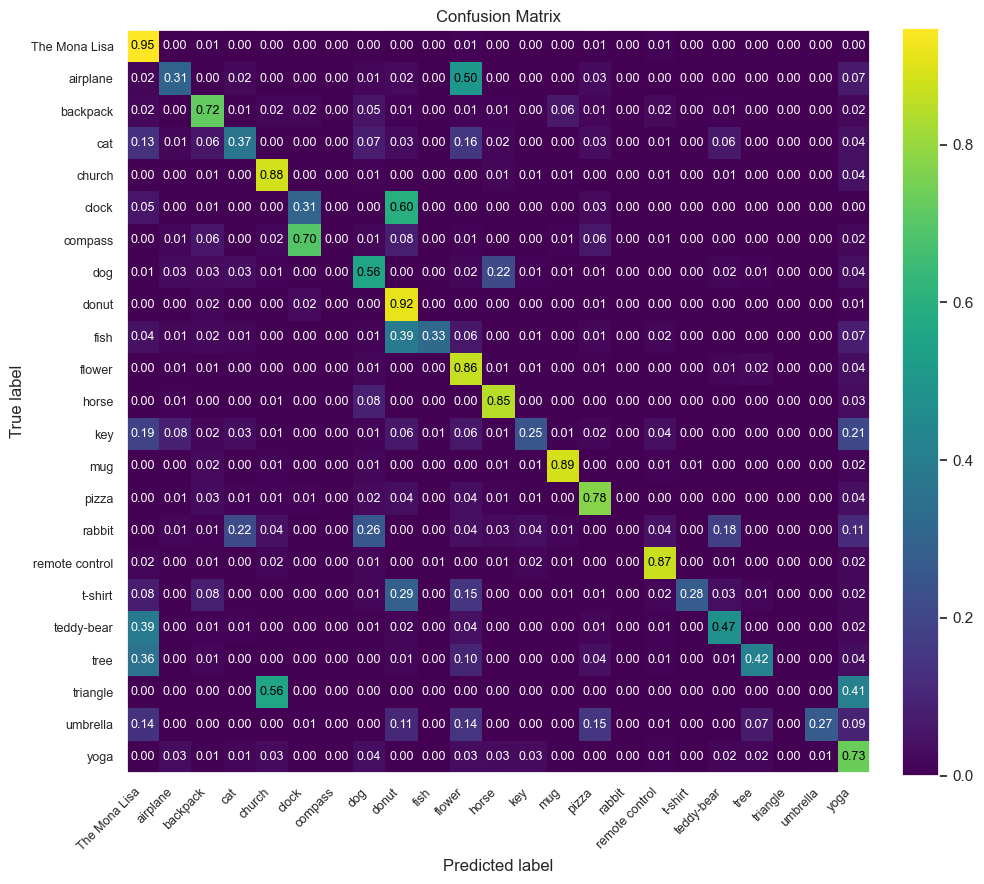

In [45]:
### This code should not be modified

y_true_E4, y_pred_E4 = extract_predictions_E4(mlp_model_E1, test_loader_E4, device=device)

cm_E4 = confusion_matrix(y_true_E4, y_pred_E4)
cm_E4 = cm_E4.astype(float) / cm_E4.sum(axis=1, keepdims=True) # Normalize by row

plot_confusion_matrix(
    cm_E4,
    class_names_E4,
    exercise="E4",
    figsize=(10, 10),
    font_size=9,
    label_size=9,
)

Something seems strange with this evaluation set.

Investigate the distribution of pixel intensities in the training set and this evaluation set. The pixel intensities refer to how much of each image is background versus stroke.

Implement the function `plot_pixel_intensities_distribution` which plots a histogram using 50 bins `density=True`.

In [46]:
# Implement
def plot_pixel_intensity_distributions(datasets, labels=None, bins=50, figsize=(6, 4)):
    """
    Plot pixel intensity distributions for one or more datasets on the same plot.

    Args:
        datasets (list): List of datasets. Each dataset is assumed to yield a tensor or array where idx[0] is the image.
        labels (list, optional): Labels for each dataset for the legend. Defaults to None.
        bins (int, optional): Number of bins for histogram. Defaults to 50.
        figsize (tuple, optional): Figure size. Defaults to (6, 4).
    """
    plt.figure(figsize=figsize)

    plt.figure(figsize=figsize)

    for i, dataset in enumerate(datasets):
        all_pixels = []

        for sample in dataset:
            img = sample[0]
            if torch.is_tensor(img):
                img = img.cpu().numpy()
            all_pixels.append(img.flatten())

        all_pixels = np.concatenate(all_pixels)

        label = labels[i] if labels is not None else None
        plt.hist(all_pixels, bins=bins, density=True, alpha=0.5, label=label)

    plt.xlabel("Pixel intensity")
    plt.ylabel("Density")
    plt.title("Pixel intensity histograms")
    if labels is not None:
        plt.legend()
    plt.tight_layout()
    plt.show()

<Figure size 600x400 with 0 Axes>

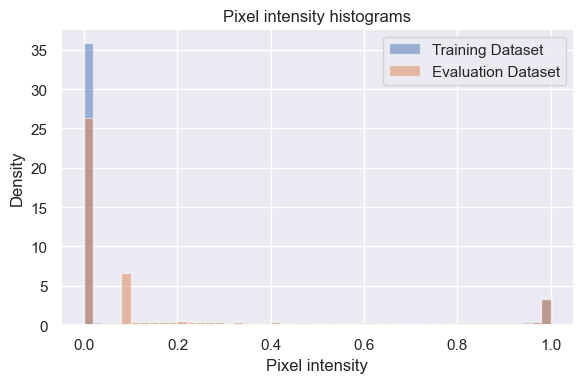

In [47]:
# Plot pixel intensity distribution:
plot_pixel_intensity_distributions([train_dataset_E4, test_dataset_E4], labels=["Training Dataset", "Evaluation Dataset"])

Do you notice any difference between the two datasets?


### Question E.6: Plot mean intensity  (2 points)
To gain even more insight into the difference between the two datasets, plot the distribution of mean intensity per drawing, a per-image statistic, for the training set and the evaluation set.

Implement the `plot_mean_intensity_distribution` function using 50 bins.

In [48]:
# Implement
def plot_mean_pixel_intensity_distributions(datasets, labels=None, bins=50, figsize=(6, 4)):
    """
    Plot mean pixel intensity distributions for one or more datasets on the same plot.

    Args:
        datasets (list): List of datasets. Each dataset is assumed to yield a tensor or array where idx[0] is the image.
        labels (list, optional): Labels for each dataset for the legend. Defaults to None.
        bins (int, optional): Number of bins for histogram. Defaults to 50.
        figsize (tuple, optional): Figure size. Defaults to (6, 4).
    """
    plt.figure(figsize=figsize)

    for i, dataset in enumerate(datasets):
        mean_intensities = []

        for sample in dataset:
            img = sample[0]
            if torch.is_tensor(img):
                img = img.cpu().numpy()
            mean_intensities.append(np.mean(img))

        label = labels[i] if labels is not None else None
        plt.hist(mean_intensities, bins=bins, density=True, alpha=0.5, label=label)

    plt.xlabel("Mean pixel intensity")
    plt.ylabel("Density")
    plt.title("Mean pixel intensity distributions")
    if labels is not None:
        plt.legend()
    plt.tight_layout()
    plt.show()

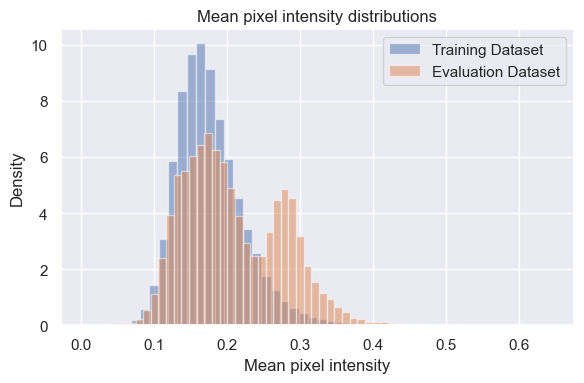

In [49]:

# Plot mean pixel intensity distribution
plot_mean_pixel_intensity_distributions([train_dataset_E4, test_dataset_E4], labels=["Training Dataset", "Evaluation Dataset"])


### Question E.7: Interpret the results (4 points)
**Base your answers to this question based on the evaluation you performed above. In addition, you are allowed to investigate the model performance and data as much as you want to help you answer the question. However, before submitting the notebook to autograder, you must remove all additional cells you included.**

**Select all correct statements below:**
- *A*. The model is overfitting: it has memorized the training examples and cannot handle even slight variations in the test set.
- *B*. Even though the overall accuracy is lower, the model is still very reliable for specific classes like *church* and *mug*.
- *C*. This model is dangerous to deploy because it classifies completely random or unknown objects with high confidence.
- *D*. The 'double-peak' shape in the evaluation set's mean pixel intensity plot suggests the data is a mix of two different types of image qualities (e.g., clean vs. noisy).
- *E*. The drop in accuracy is likely caused by the model underfitting  rather than the change in image statistics (pixel intensity).
- *F*. The model confuses *triangle* with *church* and *compass* with *clock* because the model failed to learn the subtle feature differences between these shapes during the training phase.
- *G*. The poor performance on *rabbit* class suggests that this category was significantly under-represented in the training data compared to others.

In [50]:
# Fill in the correct answer. Don't change the name of the variable
E_7_answer = "B, D"

## Section 4: Activation Functions (5 points)
Use dataset `quickdraw_subset2` for *this section.*

--------------------------------------------
In this section, we'll explore how activation functions (e.g. ReLU and sigmoid) affect model training and learning - and why they are the reason your neural network is not just doing fancy linear algebra.

Activation functions introduce non-linearity into neural networks. Without them, even a very deep network would still behave like a single linear layer…

### Model Architecture & Training
To get things started, we've prepared a hidden “reference” model called `class MLP_F1_G1`. Think of it as an overachieving MLP that really wants to learn something interesting.

**Architecture Components**:
- **Input Layer**:
    - 784 features (Yes, that's a flattened 28x28 image.)
- **Hidden Layers**:
  - 10 layers with 256 neurons each
```python
    Args:
        input_dim: Dimension of input features
        num_classes: Number of output classes
        activation_fn: Activation function
        hidden_dim: Number of units in each hidden layer
        num_layers: Number of hidden layers
```

**Why this architecture?**
- Is this the perfect model? No. Is it perfectly useful for understanding activations? Absolutely.
- Our dataset probably doesn't need 10 layers - but that's the point. A deeper network lets us observe gradient behavior, saturation, and other fun things that happen when activations are pushed to their limits.
- Batch normalization helps stabilize training, but it does not remove the impact of the chosen activation function. Dropout helps prevent potential overfitting.

### Question F.1: Train and Compare ReLU vs Sigmoid Models (2 points)

**Task**: Train two identical deep networks with different activation functions and compare their performance.

**Experimental Setup**:
1. **Model 1**: `MLP_F1_G1` with ReLU activation
2. **Model 2**: `MLP_F1_G1` with Sigmoid activation

Both models are to be trained for 20 epochs, a batch size of 128, and stored in variables `relu_results` and `sigmoid_results` respectively.

**What to observe**:
- How quickly does each model converge?
- What is the final validation accuracy for each?
- Do you notice any differences in training stability?


In [51]:
# Load the dataset
dataset_F1_G1 = AssignmentDataset(os.path.join(root_dir, "data/quickdraw_subset2"))
num_classes_F1_G1 = len(dataset_F1_G1.classes)
input_dim = 28 * 28
criterion=nn.CrossEntropyLoss()

In [52]:
# Implement
def relu_model(device):
    model = MLP_F1_G1(
        input_dim=input_dim,
        num_classes=num_classes_F1_G1,
        activation_fn=nn.ReLU
    ).to(device)
    return model

In [53]:
validation.signature_unchanged(relu_model)

In [54]:
relu_instance = relu_model(device)
relu_results = train_model(relu_instance,
                           dataset_F1_G1,
                           criterion=nn.CrossEntropyLoss(),
                           optimizer = optim.Adam(relu_instance.parameters(), lr=1e-3),
                           batch_size=128,
                           epochs=NUM_EPOCHS_TO_RUN,
                           device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/1094 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1/20 | Training loss: 1.2719 | Training acc: 0.6267 | Validation loss: 0.9060 | Validation acc: 0.7356


  0%|          | 0/1094 [00:00<?, ?it/s]

...

  0%|          | 0/1094 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 20/20 | Training loss: 0.4819 | Training acc: 0.8579 | Validation loss: 0.5973 | Validation acc: 0.8281


  0%|          | 0/157 [00:00<?, ?it/s]

Test loss: 0.5864 | Test acc: 0.8328


In [55]:
# Implement
def sigmoid_model(device):
    model = MLP_F1_G1(
        input_dim=input_dim,
        num_classes=num_classes_F1_G1,
        activation_fn=nn.Sigmoid
    ).to(device)
    return model

In [56]:
validation.signature_unchanged(sigmoid_model)

In [57]:
sigmoid_instance = sigmoid_model(device)
sigmoid_results = train_model(sigmoid_instance,
                              dataset_F1_G1,
                              criterion=nn.CrossEntropyLoss(),
                              optimizer = optim.Adam(sigmoid_instance.parameters(), lr=1e-3),
                              batch_size=128,
                              epochs=NUM_EPOCHS_TO_RUN,
                              device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/1094 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1/20 | Training loss: 1.8259 | Training acc: 0.4454 | Validation loss: 1.5198 | Validation acc: 0.5470


  0%|          | 0/1094 [00:00<?, ?it/s]

...

  0%|          | 0/1094 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 20/20 | Training loss: 0.7099 | Training acc: 0.7934 | Validation loss: 0.6975 | Validation acc: 0.7977


  0%|          | 0/157 [00:00<?, ?it/s]

Test loss: 0.6749 | Test acc: 0.8022


### Question F.2: Visualize Learning Curves (1 point)

**Task**: Create comparison plots for the two models using the provided helper function.

**Instructions**:
Write a function `results_dict` that returns a dictionary containing your results, which you will use when calling `plot_learning_curves`.
```python
{
    'Model Name 1': model1_results,
    'Model Name 2': model2_results
}
```

**What to look for**:
- **Comparison**: Which model learns faster? Which achieves higher final accuracy?

In [58]:
# Implement
def results_dict(relu_results, sigmoid_results):
    return {
        "ReLU": relu_results,
        "Sigmoid": sigmoid_results
    }

In [59]:
validation.signature_unchanged(results_dict)

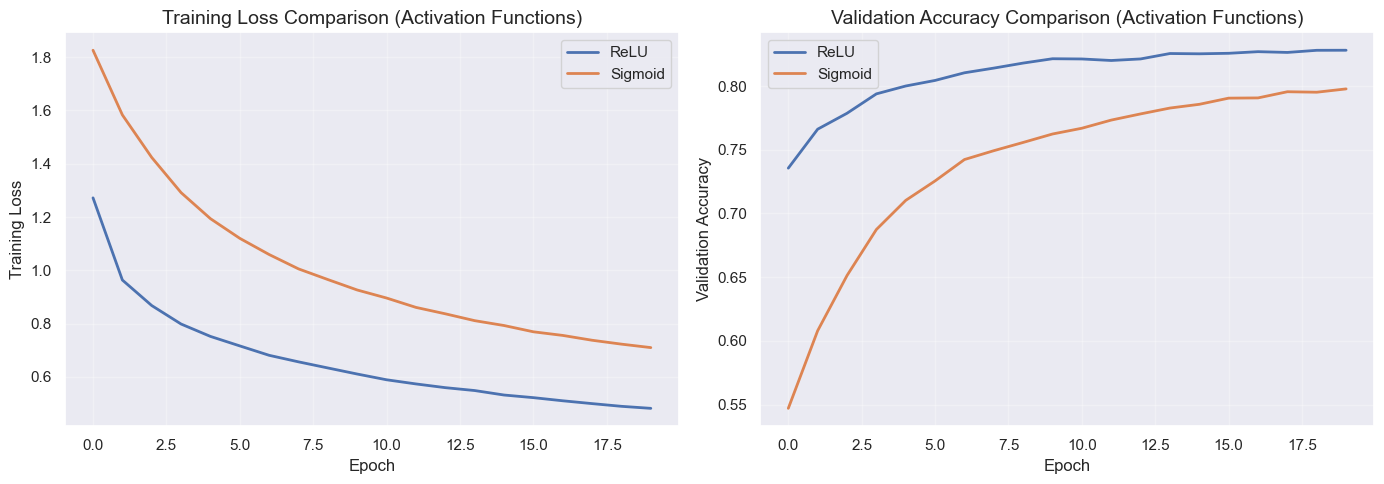

In [60]:
plot_learning_curves(results_dict(relu_results, sigmoid_results), title_suffix='(Activation Functions)')


### Question F.3: Interpretation (2 points)
**Based on your theoretical understanding, experiments and observations, select ***all correct answers***. There may be more than one correct option!**
- *A*. As layers deepen during backpropagation, ReLU could be more susceptible to the problem of vanishing gradients
- *B*. As layers deepen during backpropagation, Sigmoid could be more susceptible to the problem of vanishing gradients
- *C*. Sigmoid converges faster because it squashes input values between 0 and 1.
- *D*. ReLU exhibits faster convergence because its gradient does not saturate for positive input values.
- *E*. The weights in the earlier layers are initialized to be much smaller than those in the later layers.
- *F*. The Chain Rule involves a product of derivatives; when these derivatives are small (as with sigmoid activations), gradients diminish as they are backpropagated.
- *G*. The Chain Rule causes gradients to vanish in deep networks regardless of the activation function; therefore, ReLU also suffers from vanishing gradients as depth increases.


**Think about**:
- How did training loss curves differ between models?
- Which model achieved higher final accuracy?

In [61]:
# Fill in the correct answer. Don't change the name of the variable
Q_F_3 = 'B, D, F'


# Convolutional neural networks

## Section 5: Interpreting models (3 points)

### Question I.1 Fetch activations (1 point)
Write a class `ActivationMap` to return the activations of a given model (using a hook function). Refer to the lecture notes and slides for an example.
We will use it in the next questions to plot the activation maps.

In [62]:
# Implement
class ActivationMap:
    def __init__(self, model):
        self.model = model
        self.outputs = []
        self.hooks = []

        conv_layers = []
        for module in self.model.modules():
            if isinstance(module, nn.Conv2d):
                conv_layers.append(module)

        for layer in conv_layers[:2]:
            hook = layer.register_forward_hook(self.hook_fn)
            self.hooks.append(hook)

    def hook_fn(self, module, input, output):
        self.outputs.append(output.detach().cpu())
    
    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

### Question I.2 Create activation maps (2 points)
Retrieve some samples for the classes `triangle`, `tent`, `flower` and `tree`. Per class, plot the activation map of five data samples on the first two layers.
You only need to correctly create the plots now, we'll ask more questions later. 

In [63]:
## This code should not be modified
dataset_I2 = DatasetInterpret(Path(root_dir))

In [64]:
# Implement
def get_samples_per_class(dataset, num_samples=5):
    target_classes = ["triangle.npy", "tent.npy", "flower.npy", "tree.npy"]
    class_to_idx = {name: i for i, name in enumerate(dataset.classes)}
    target_class_ids = [class_to_idx[name] for name in target_classes]

    class_counts = {class_id: 0 for class_id in target_class_ids}
    images = []
    labels = []

    dataset_iter = iter(dataset)

    while True:
        try:
            img, label = next(dataset_iter)
            label = int(label)

            if label in class_counts and class_counts[label] < num_samples:
                images.append(img)
                labels.append(label)
                class_counts[label] += 1

            if all(count >= num_samples for count in class_counts.values()):
                break

        except StopIteration:
            break

    return images, labels

def plot_activation_maps(activation_map, images, labels, class_names):
    num_images = len(images)

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 3 * num_images))
    if num_images == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_images):
        img = images[i].squeeze().cpu().numpy()
        label_name = class_names[int(labels[i])]

        fmap1 = activation_map.outputs[0][i].mean(dim=0).cpu().numpy()
        fmap2 = activation_map.outputs[1][i].mean(dim=0).cpu().numpy()

        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].axis("off")
        axes[i, 0].set_title(f"Input: {label_name}")

        axes[i, 1].imshow(fmap1, cmap="viridis")
        axes[i, 1].axis("off")
        axes[i, 1].set_title("conv1")

        axes[i, 2].imshow(fmap2, cmap="viridis")
        axes[i, 2].axis("off")
        axes[i, 2].set_title("conv2")

    plt.tight_layout()
    plt.show()

In [65]:
validation.signature_unchanged(get_samples_per_class)

In [66]:
validation.signature_unchanged(plot_activation_maps)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1489 [00:00<?, ?it/s]

  0%|          | 0/426 [00:00<?, ?it/s]

Epoch 1/10 | Training loss: 0.1938 | Training acc: 0.9331 | Validation loss: 0.1472 | Validation acc: 0.9494


  0%|          | 0/1489 [00:00<?, ?it/s]

...

  0%|          | 0/1489 [00:00<?, ?it/s]

  0%|          | 0/426 [00:00<?, ?it/s]

Epoch 10/10 | Training loss: 0.0150 | Training acc: 0.9947 | Validation loss: 0.3327 | Validation acc: 0.9490


  0%|          | 0/213 [00:00<?, ?it/s]

Test loss: 0.3465 | Test acc: 0.9493


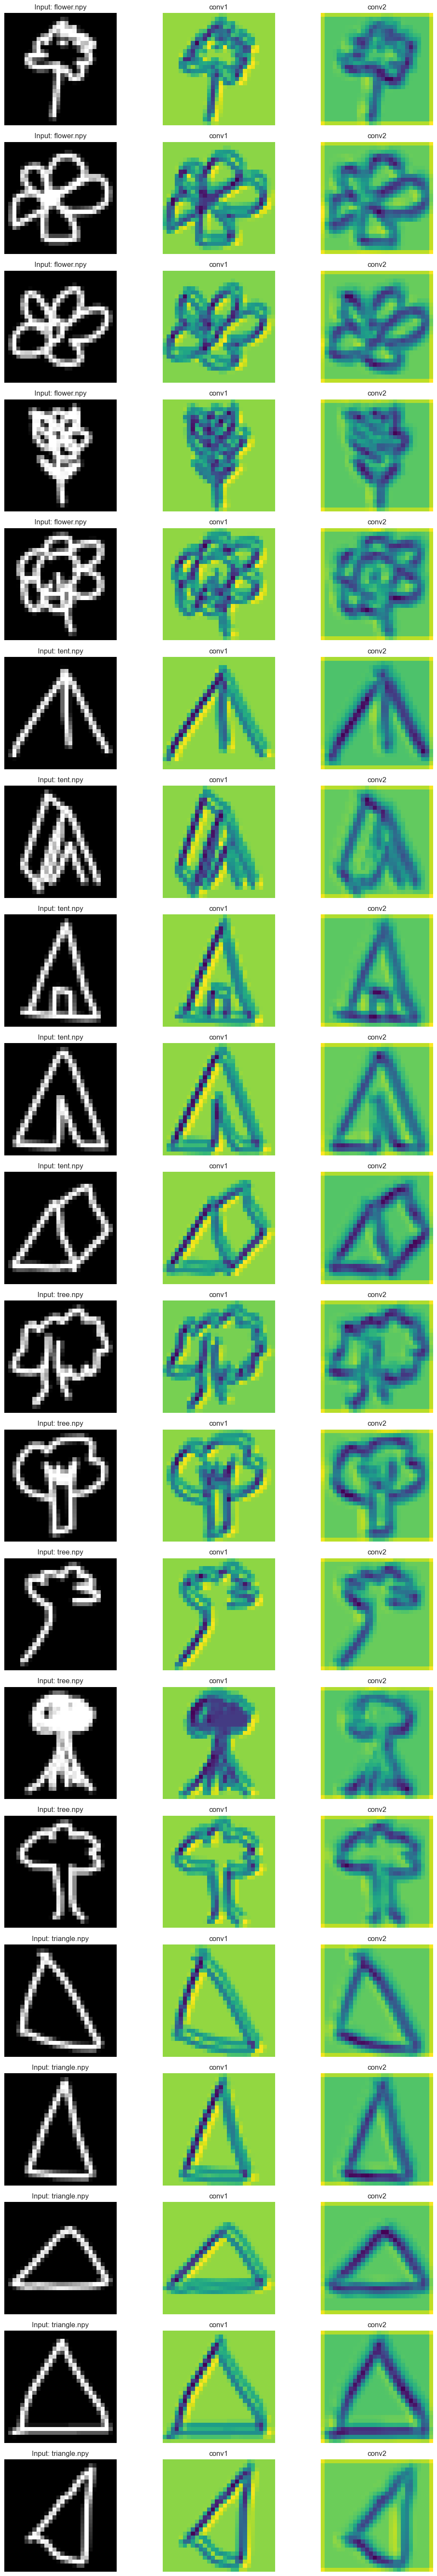

In [67]:
images, labels = get_samples_per_class(dataset_I2, num_samples=5)

input_batch = torch.stack(images).to(device)

model_interpret = SimpleCNNModel(len(dataset_I2.classes)).to(device)
if NUM_EPOCHS_TO_RUN > 1:
     train_model(model=model_interpret,
            dataset=dataset_I2,
            criterion=nn.CrossEntropyLoss(),
            optimizer=Adam(model_interpret.parameters(), lr=1e-3),
            device=device,
            batch_size=128,
            epochs=10)

activation_map = ActivationMap(model_interpret)

activation_map.outputs = []
model_interpret.eval()
with torch.no_grad():
    _ = model_interpret(input_batch)

plot_activation_maps(activation_map, images, labels, dataset_I2.classes)

# Remove hooks after use
activation_map.remove_hooks()

## Section 6: Pooling (6 points)

Pooling layers are very important in convolutional neural networks to spread pixel information to all neurons in deeper layers. In this questions we'll study this in more detail.

### Question P.1: Max pooling (1 point)
Implement and train a simple CNN model with a max pooling layer.

In [68]:
# Implement
class CNNMaxPool(nn.Module):
    def __init__(self, num_classes, device=torch.device("cpu")):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [69]:

data_pooling = DatasetInterpret(root_dir)
model_maxpool = CNNMaxPool(len(data_pooling.classes)).to(device)
criterion_pooling = nn.CrossEntropyLoss()
optimizer_maxpool = Adam(model_maxpool.parameters(), lr=1e-3)
train_model(model=model_maxpool,
              dataset=data_pooling,
              criterion=criterion_pooling,
              optimizer=optimizer_maxpool,
              batch_size=128,
              epochs=NUM_EPOCHS_TO_RUN,
              device=device)



  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/1489 [00:00<?, ?it/s]

  0%|          | 0/426 [00:00<?, ?it/s]

Epoch 1/20 | Training loss: 0.2641 | Training acc: 0.9105 | Validation loss: 0.1959 | Validation acc: 0.9355


  0%|          | 0/1489 [00:00<?, ?it/s]

...

  0%|          | 0/426 [00:00<?, ?it/s]

Epoch 20/20 | Training loss: 0.1190 | Training acc: 0.9585 | Validation loss: 0.1430 | Validation acc: 0.9524


  0%|          | 0/213 [00:00<?, ?it/s]

Test loss: 0.1445 | Test acc: 0.9522


{'train_accuracy': [0.9105317590730834,
  0.937605325465532,
  0.9426399483413044,
  0.9460576120452958,
  0.9482205574309248,
  0.9500895102398664,
  0.9509714879699288,
  0.9517222190139699,
  0.9530871845485901,
  0.9535071739438579,
  0.9542684047227807,
  0.9551713819226064,
  0.9557173681364546,
  0.9565573469269901,
  0.9563631018316787,
  0.9571925808873326,
  0.9574340747896115,
  0.9576650689570089,
  0.9585312970847486,
  0.9585312970847486],
 'val_accuracy': [0.935468460026092,
  0.9416790695110523,
  0.9452069896918582,
  0.946217591826985,
  0.9484592911085387,
  0.9489737794682396,
  0.9493596457380151,
  0.9482939198500634,
  0.9511971041655183,
  0.9506826158058174,
  0.950443746210242,
  0.951638094188119,
  0.9503702478731418,
  0.9519872112893446,
  0.9520055858736196,
  0.9499660070190912,
  0.9520055858736196,
  0.952207706300645,
  0.9513992245925436,
  0.9524282013119453],
 'train_loss': [0.2641256636985516,
  0.1873884790142466,
  0.17047319406965453,
  0.15993

### Question P.2: Average pooling (1 point)
Implement and train a simple CNN model with average pooling layers.

In [70]:
# Implement
class CNNAvgPool(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [71]:

data_pooling = DatasetInterpret(root_dir)
model_avgpool = CNNAvgPool(len(data_pooling.classes)).to(device)
criterion_pooling = nn.CrossEntropyLoss()
optimizer_avgpool = Adam(model_avgpool.parameters(), lr=1e-3)
train_model(model=model_avgpool,
              dataset=data_pooling,
              criterion=criterion_pooling,
              optimizer=optimizer_avgpool,
              epochs=NUM_EPOCHS_TO_RUN,
              batch_size=64,
              device=device)


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/2977 [00:00<?, ?it/s]

  0%|          | 0/851 [00:00<?, ?it/s]

Epoch 1/20 | Training loss: 0.2718 | Training acc: 0.9089 | Validation loss: 0.2003 | Validation acc: 0.9351


  0%|          | 0/2977 [00:00<?, ?it/s]

...

  0%|          | 0/851 [00:00<?, ?it/s]

Epoch 20/20 | Training loss: 0.1273 | Training acc: 0.9568 | Validation loss: 0.1387 | Validation acc: 0.9533


  0%|          | 0/426 [00:00<?, ?it/s]

Test loss: 0.1401 | Test acc: 0.9537


{'train_accuracy': [0.9088728009617757,
  0.9350748893590437,
  0.9404455037510303,
  0.9437056714317964,
  0.9459473648290381,
  0.94794231445656,
  0.9494752757492874,
  0.9509819877048105,
  0.950960988235047,
  0.9524834497928927,
  0.9528036917067844,
  0.9535124238112987,
  0.9539901617484159,
  0.9544521500832104,
  0.9548301405389514,
  0.955601871052756,
  0.9557908662806264,
  0.9559641119061744,
  0.9564943485176999,
  0.9568303400339141],
 'val_accuracy': [0.9351193429248663,
  0.9392719989710233,
  0.9436818991970307,
  0.94623596641126,
  0.9466585818495856,
  0.9487900336254892,
  0.9491575253109898,
  0.9500211307719163,
  0.9508296124800176,
  0.9513441008397185,
  0.9507193649743675,
  0.9516932179409441,
  0.9526303217389707,
  0.9515462212667438,
  0.9518402146151443,
  0.9513992245925436,
  0.9528140675817209,
  0.9521158333792697,
  0.9532366830200467,
  0.9532550576043217],
 'train_loss': [0.2718381504834907,
  0.1962611579165799,
  0.17941863830602275,
  0.16890

### Question P.3: Activation maps revisited (2 points)
Plot the activation maps of each model on a data sample.

In [72]:
# Implement
def plot_activation_maps_pooling(models, hooks:dict):
    sample_img, sample_label = data_pooling[0]
    input_img = sample_img.unsqueeze(0).to(device)

    fig, axes = plt.subplots(len(models), 2, figsize=(8, 4 * len(models)))
    if len(models) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, (model_name, model) in enumerate(models.items()):
        model.eval()
        hooks[model_name].outputs = []

        with torch.no_grad():
            _ = model(input_img)

        for col in range(2):
            fmap = hooks[model_name].outputs[col][0]   # first image in batch
            fmap = fmap.mean(dim=0).numpy()            # average across channels

            axes[row, col].imshow(fmap, cmap="viridis")
            axes[row, col].axis("off")
            axes[row, col].set_title(f"{model_name} - Layer {col + 1}")

    plt.tight_layout()
    plt.show()

In [73]:
validation.signature_unchanged(plot_activation_maps_pooling)

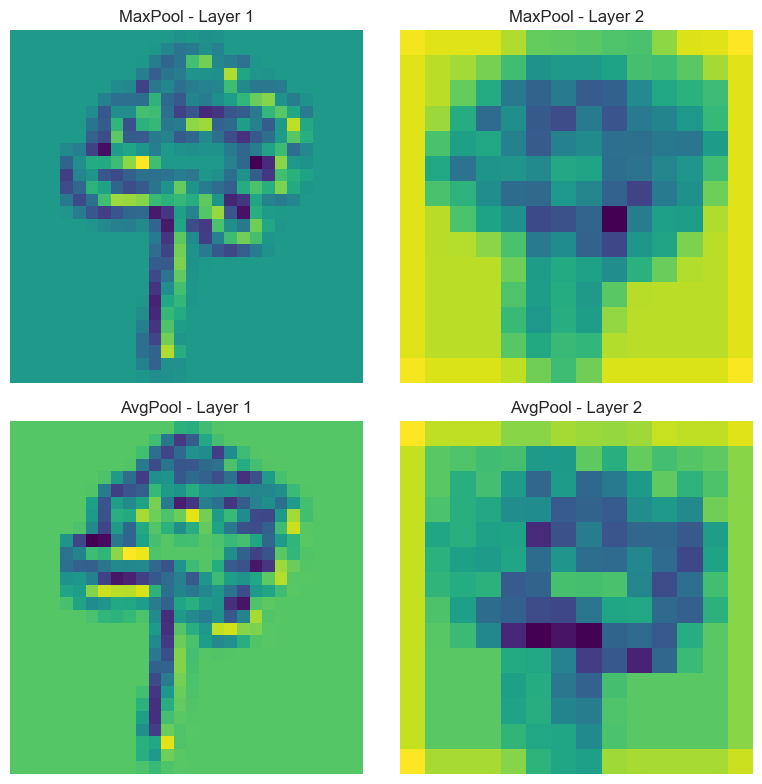

In [74]:
models = {'MaxPool': model_maxpool, 'AvgPool': model_avgpool}
hooks = {name: ActivationMap(models[name]) for name in models}
plot_activation_maps_pooling(models, hooks)

### Question P.4: Interpretation (2 points)
**Which of the following statements about max pooling and average poolng is correct? ***Select all statements that apply.*****
- *A.* Max pooling is generally more suitable than average pooling for this dataset. It preserves the strongest local stroke responses, while suppressing large empty background regions.
- *B.* Average pooling is preferable because it better captures global shape information and reduces sensitivity to local stroke placement.
- *C.* Using average pooling in early layers is likely to blur thin strokes in this dataset.
- *D.* Average pooling is guaranteed to outperform max pooling on sparse binary or near-binary inputs, such as the items in this dataset.
- *E.* Replacing all max pooling layers with average pooling layers will increase the influence of the background pixels in the images more.
- *F.* The choice between max and average pooling has no interaction with the sparsity of the input representation.


In [75]:
# Implement
Q_P_4_answer = "A, C, E"

## Section 7: Data augmentation (10 points)
Finally, we'll study how data augmentation affects a model's generalizability.
You will load in a subset of the *Quick, Draw!* dataset consisting of the classes `fork` and `spoon`.

We'll start by splitting the data into a completely separate training and test set, training a `SimpleCNNModel()` on the raw training data (without any augmentations), and test it on the test set using `evaluate(model, dataloader, criterion, device)`.

In [76]:
# These functions return training and test samples according to a specific data split. 
# They don't apply any data unaugmentation.
data_aug_train = DatasetAugmentationTrain(root_dir)
data_aug_test = DatasetAugmentationTest(root_dir)

model_aug = SimpleCNNModel(len(data_aug_train.classes)).to(device)
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = Adam(model_aug.parameters(), lr=1e-3)

train_model(model_aug,
            data_aug_train,
            criterion=criterion_aug,
            optimizer=optimizer_aug,
            epochs=NUM_EPOCHS_TO_RUN,
            batch_size=128,
            device=device)

data_aug_test_loader = DataLoader(data_aug_test, batch_size=256, shuffle=False)

test_loss, test_acc = evaluate(model_aug, data_aug_test_loader, device=device, criterion=criterion_aug)
print(f"Test loss: {test_loss} | Test acc: {test_acc}")

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/20 | Training loss: 0.1000 | Training acc: 0.9636 | Validation loss: 0.0237 | Validation acc: 0.9920


  0%|          | 0/35 [00:00<?, ?it/s]

...

Epoch 20/20 | Training loss: 0.0000 | Training acc: 1.0000 | Validation loss: 0.0020 | Validation acc: 0.9992


  0%|          | 0/5 [00:00<?, ?it/s]

Test loss: 0.0255 | Test acc: 0.9952


  0%|          | 0/466 [00:00<?, ?it/s]

Test loss: 4.5848925785033545 | Test acc: 0.696027633851468


### Question A.1: Interpretation (1 point)
**Observe the accuracy on the entirely held-out test examples. Does the model generalize well over this data? ***Select the correct statements:*****
- *A.* Yes.
- *B.* No.
- *C.* The training and test classification accuracy are good.
- *D.* The model overfits on the training data.
- *E.* The model underfits on the training data.

In [77]:
# Implement
A_1_answer = "B, D"

### Question A.2: Observing variations in the data (1 point)
To do data augmentation we need to understand how test data can be different from the training data, so we can (hopefully) augment the training data to be more representative. Write a function `plot_samples(dataset, title, num_samples)` that simply plots many samples of the training data and test data using `matplotlib`. Observe in what ways the training data might be biased.

In [78]:
# Implement
def plot_samples(dataset, title, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(3 * num_samples, 3))

    for i in range(num_samples):
        img, label = dataset[i]

        if torch.is_tensor(img):
            img = img.squeeze().cpu().numpy()

        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")

        if hasattr(dataset, "classes"):
            class_name = dataset.classes[int(label)]
            axes[i].set_title(class_name)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [79]:
validation.signature_unchanged(plot_samples)

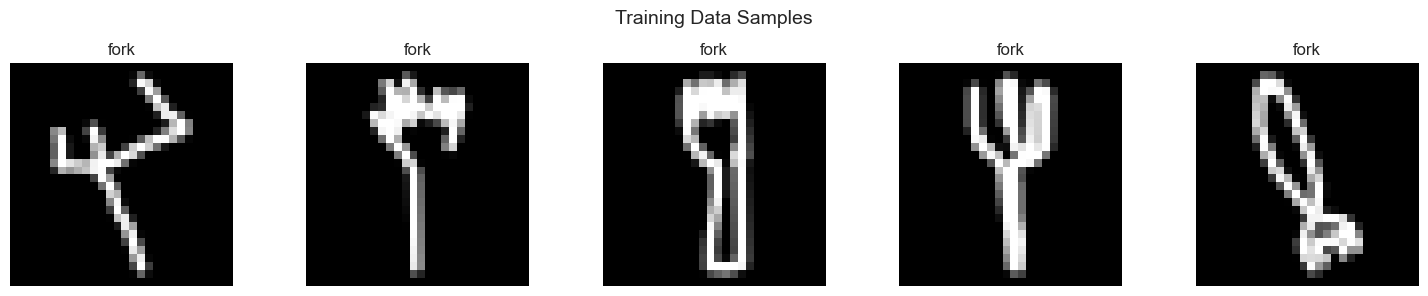

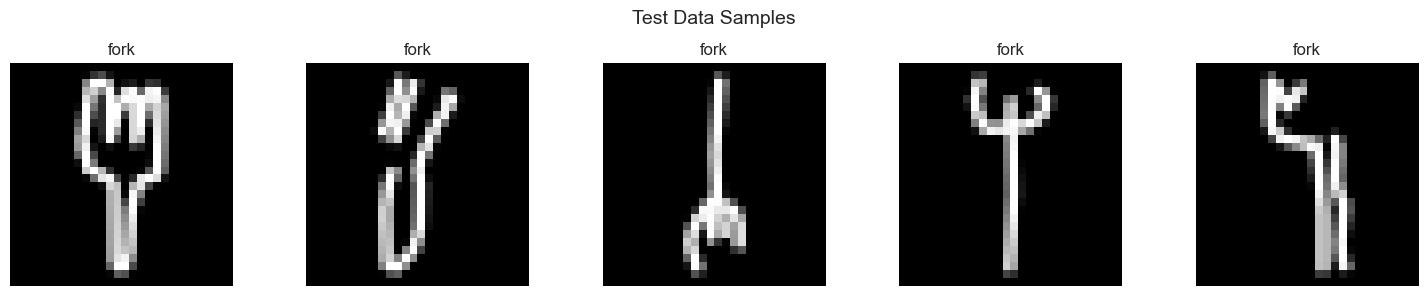

In [80]:
# Do not change this code  
plot_samples(data_aug_train, "Training Data Samples")
plot_samples(data_aug_test, "Test Data Samples")

### Question A.3: Observing variations in activation maps (2 point)
Plot the activation map of the samples used in A.3 for the first 2 layers of the model. You can write your own function, or reuse the implementation from the *Model Interpretability* section. Observe what parts of the drawing the model is paying attention to. Does it seem like it's looking at the most salient attributes of spoons and forks, or does it look confused? 

In [81]:
# Implement
def plot_activation_maps_aug(model, dataset, title, num_samples=5):
    outputs = []

    def hook_fn(module, inp, out):
        outputs.append(out.detach().cpu())

    h1 = model.conv1.register_forward_hook(hook_fn)
    h2 = model.conv2.register_forward_hook(hook_fn)

    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    model.eval()

    with torch.no_grad():
        for i in range(num_samples):
            img, label = dataset[i]
            x = img.unsqueeze(0).to(device)

            outputs.clear()
            _ = model(x)

            img_np = img.squeeze().cpu().numpy()
            axes[i, 0].imshow(img_np, cmap="gray")
            axes[i, 0].axis("off")

            if hasattr(dataset, "classes"):
                axes[i, 0].set_title(f"Input: {dataset.classes[int(label)]}")
            else:
                axes[i, 0].set_title("Input")

            fmap1 = outputs[0][0].mean(dim=0).numpy()
            fmap2 = outputs[1][0].mean(dim=0).numpy()

            axes[i, 1].imshow(fmap1, cmap="viridis")
            axes[i, 1].axis("off")
            axes[i, 1].set_title("conv1")

            axes[i, 2].imshow(fmap2, cmap="viridis")
            axes[i, 2].axis("off")
            axes[i, 2].set_title("conv2")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    h1.remove()
    h2.remove()

In [82]:
validation.signature_unchanged(plot_activation_maps_aug)

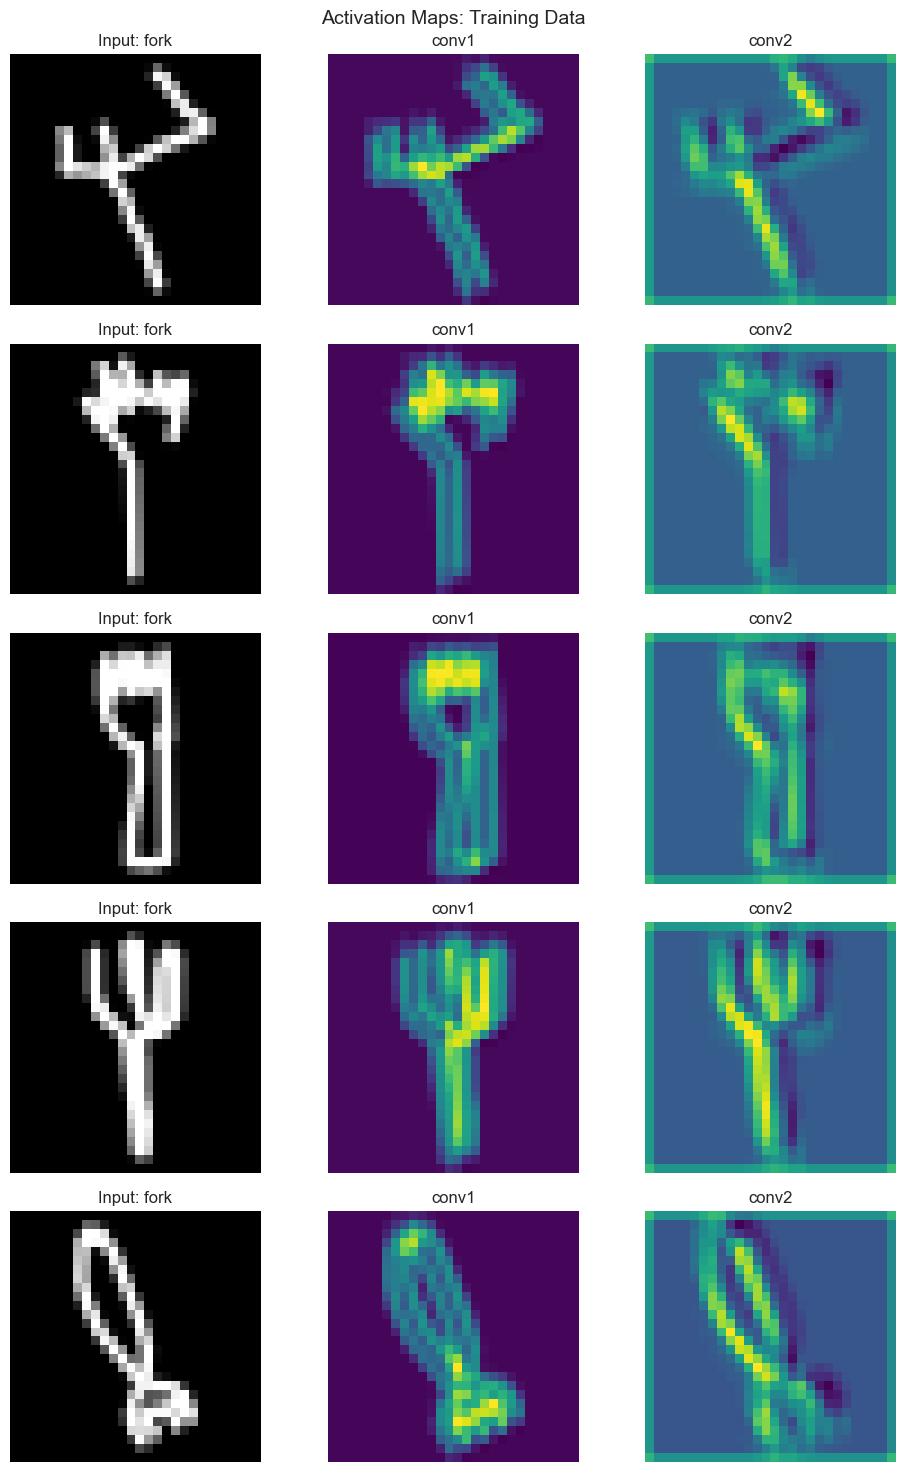

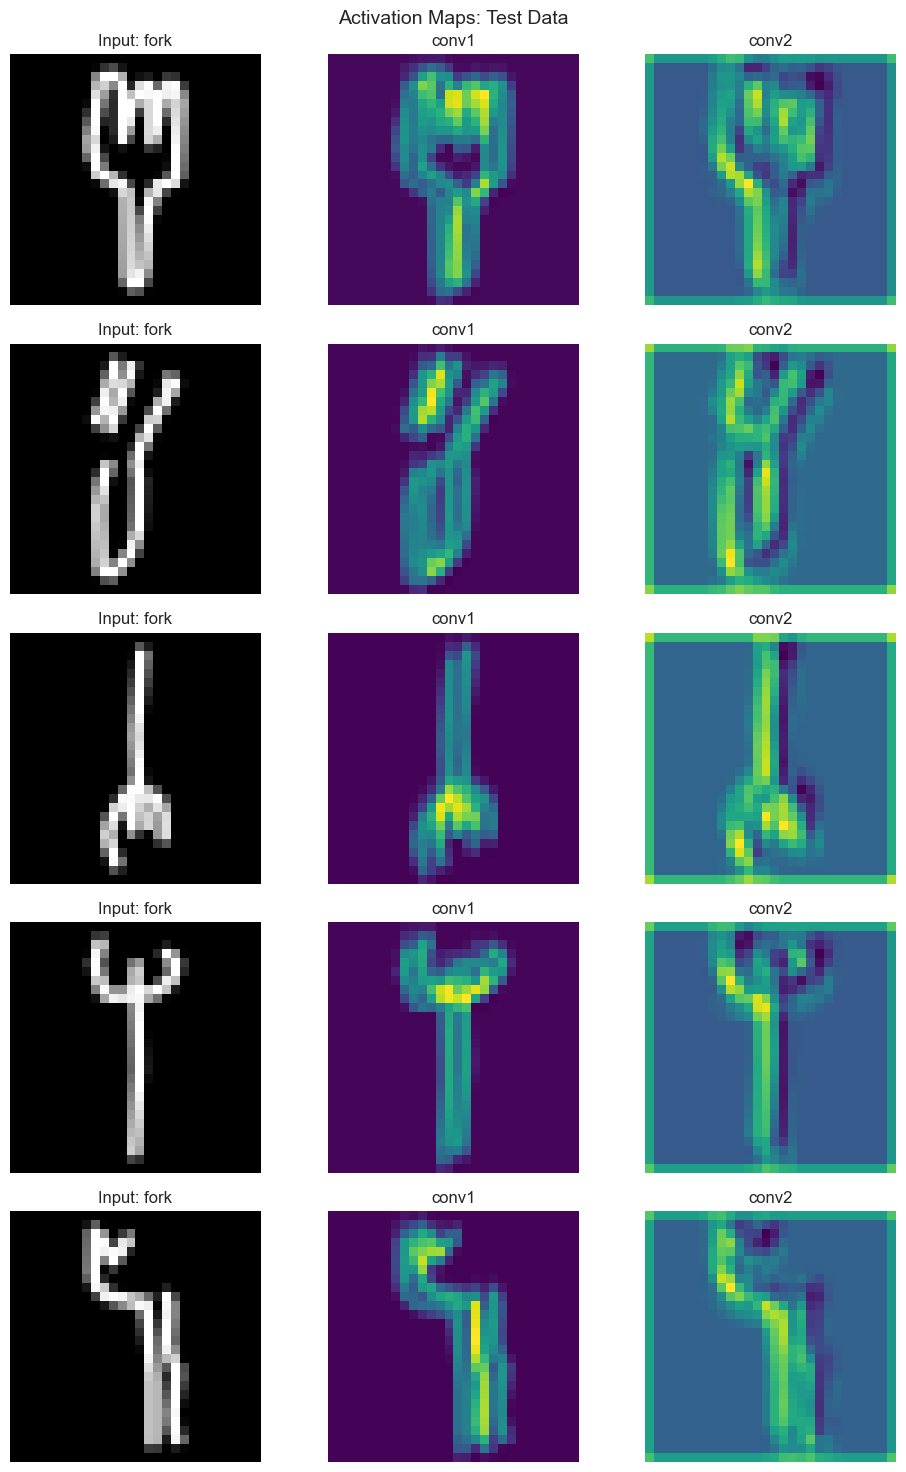

In [83]:
### Do not change this code
plot_activation_maps_aug(model_aug, data_aug_train, "Activation Maps: Training Data")
plot_activation_maps_aug(model_aug, data_aug_test, "Activation Maps: Test Data")

### Question A.4: Interpretation (2 points)
**Which  of the following transformations are appropriate for increasing data diversity, while preserving class semantics in this specific dataset? ***Select all statements that apply.*****
- *A.* Random rotations within a wide angle range (e.g., 90 degrees)
- *B.* Horizontal and vertical flips
- *C.* Small translations and uniform scaling
- *D.* Color jittering and brightness adjustments
- *E.* Stroke-level noise or slight perturbations of stroke coordinates
- *F.* Large non-uniform scaling that distorts aspect ratios
- *G.* Random stroke deletion

In [84]:
# Don't change the name of the variable
A_4_answer = "A, C, E"

### Question A.5: Data augmentation (2 points)
Augment the data: use a `torchvision.transforms`  pipeline to apply all transformations that you deem relevant.
Simply implement the pipeline here. You will use it in the next question to augment the training data.

In [85]:
# Implement
def transform_pipeline():
    return v2.Compose([
        v2.RandomRotation(30),
        v2.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1)
        ),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
    ])

### Question A.6: Re-evaluate (2 points)
Retrain the model you trained in A.1 with the augmented data from A.5. Training a `SimpleCNNModel()` on the augmented training data. Then, evaluate it as before. Did the accuracy on the test set improve (or did it get worse)?

In [86]:
# Implement
def train_model_augmented(root_dir, transform_pipeline, device):
    """
    Returns:  
    - a simple CNN model trained on augmented data using the provided transform pipeline.
    - a data loader with the (unaugmented) test data
    - the criterion used for training and evaluation (cross entropy loss)
    """
    train_dataset_aug = DatasetAugmentationTrain(root_dir, transform=transform_pipeline())
    test_dataset_eval = DatasetAugmentationTest(root_dir)

    aug_model = SimpleCNNModel(len(train_dataset_aug.classes)).to(device)

    aug_criterion = nn.CrossEntropyLoss()
    aug_optimizer = Adam(aug_model.parameters(), lr=1e-3)

    train_model(
        model=aug_model,
        dataset=train_dataset_aug,
        criterion=aug_criterion,
        optimizer=aug_optimizer,
        device=device,
        batch_size=128,
        epochs=NUM_EPOCHS_TO_RUN
    )

    test_loader_aug = DataLoader(test_dataset_eval, batch_size=256, shuffle=False)

    return aug_model, test_loader_aug, aug_criterion

In [87]:
validation.signature_unchanged(train_model_augmented)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/20 | Training loss: 0.6029 | Training acc: 0.7171 | Validation loss: 0.4764 | Validation acc: 0.7841


  0%|          | 0/35 [00:00<?, ?it/s]

...

Epoch 20/20 | Training loss: 0.1939 | Training acc: 0.9272 | Validation loss: 0.1984 | Validation acc: 0.9323


  0%|          | 0/5 [00:00<?, ?it/s]

Test loss: 0.1822 | Test acc: 0.9364


  0%|          | 0/466 [00:00<?, ?it/s]

Test loss: 0.1845342210405483 | Test acc: 0.9349900229723158


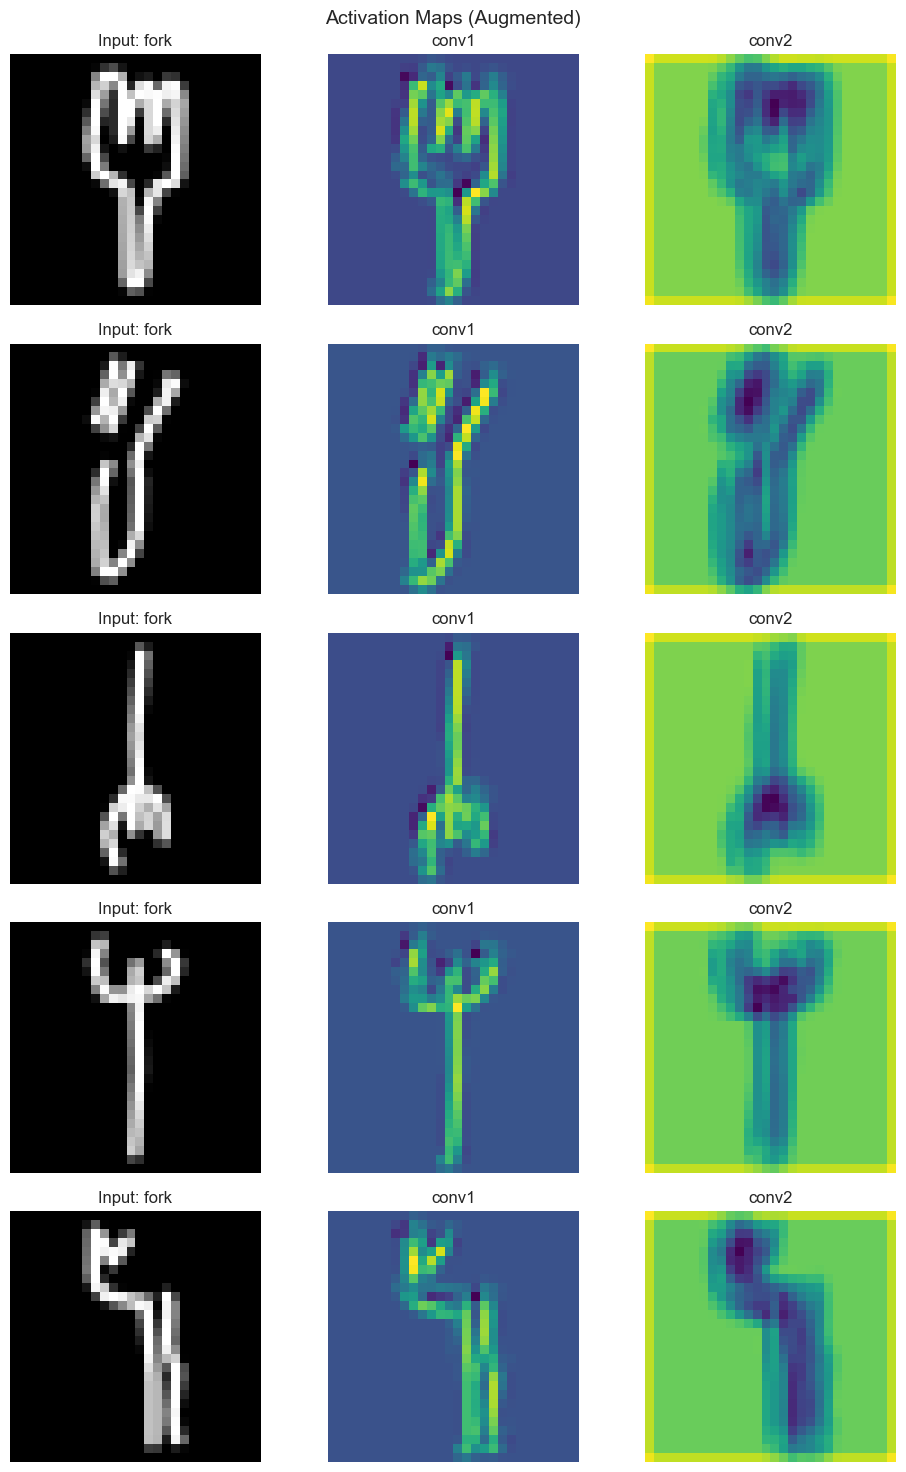

In [88]:
# Evaluate the model trained on augmented data
model_aug_transformed, data_aug_test_loader, criterion_aug = train_model_augmented(root_dir, transform_pipeline, device=device)
test_loss, test_acc = evaluate(model_aug_transformed, data_aug_test_loader, device=device, criterion=criterion_aug)
print(f"Test loss: {test_loss} | Test acc: {test_acc}")

# Plot the activation maps of the model trained on augmented data
plot_activation_maps_aug(model_aug_transformed, data_aug_test, "Activation Maps (Augmented)")

# Canvas inference
For fun, this is a sandbox you can use to test your models on your own pictures!
## Usage
- Run cell 1-3
- Draw whatever you like on the canvas. You can clear the canvas with `clear_canvas()`
- Run prediction with cell 4 using any model from the above.

In [89]:
# # Cell 1
# def clear_canvas():
#     canvas.fill_style = 'black'
#     canvas.fill_rect(0, 0, size, size)

# def canvas_to_tensor():
#     """
#     Returns a tensor of shape [1, 1, 28, 28]
#     """
#     img = canvas.get_image_data()[:, :, 0]  # take one channel
#     img = img.astype(np.float32) / 255.0
#     tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
#     return tensor


In [90]:
# # Cell 2
# label_dict = {}
# for idx, cls in enumerate(sorted(os.listdir("./data/quickdraw_subset1/"))):
#     label_dict[idx] = cls.split('.')[0]  # remove .npy extension    

# print("Draw one of:", list(label_dict.values()))

In [91]:
# # Cell 3
# size = 28
# canvas = Canvas(width=size, height=size, sync_image_data=True)
# canvas.layout.width = f"{4 * size}px"
# canvas.layout.height = f"{4 * size}px"

# canvas.fill_style = 'black'
# canvas.fill_rect(0, 0, size, size)

# drawing = {"active": False}

# def start_draw(x, y):
#     drawing["active"] = True

# def stop_draw(x, y):
#     drawing["active"] = False

# def draw(x, y):
#     if drawing["active"]:
#         canvas.fill_style = 'white'
#         canvas.fill_rect(x, y, 1, 1)

# canvas.on_mouse_down(start_draw)
# canvas.on_mouse_up(stop_draw)
# canvas.on_mouse_move(draw)

# display(canvas)


In [92]:
# clear_canvas()

In [93]:
# # Cell 4
# def quick_trainer(model, device):
#     with torch.no_grad():
#         x = canvas_to_tensor().to(device)
#         logits = model(x)
#         prediction = logits.argmax(dim=1).item()

#     return prediction

# prediction = quick_trainer(mlp_model_E1, device)
# print(label_dict[prediction])